In [1]:
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
import os.path as op
import math
import os
import h5py

from elixer import global_config as G
G.GLOBAL_LOGGING = True
from elixer import spectrum_utilities as ESU
from elixer import catalogs


from hetdex_api.elixer_widget_cls import ElixerWidget
from hetdex_api.config import HDRconfig
from hetdex_tools.get_spec import get_spectra
from hetdex_api.shot import *
from hetdex_api.survey import FiberIndex

import inspect
import scipy.stats as stats
from astropy.table import QTable, Table, Column
import warnings
from astropy.modeling import models
from specutils.spectra import Spectrum1D, SpectralRegion
from specutils.fitting import fit_generic_continuum
from specutils.fitting.continuum import fit_continuum
from astropy.stats import biweight_location
from scipy.integrate import quad as quad
from numpy.polynomial.polynomial import polyfit
from numpy.polynomial.polynomial import polyval
from photutils.centroids import centroid_2dg, centroid_sources
from numpy import inf

from matplotlib.widgets import Button

from astropy.modeling import fitting

from tqdm.notebook import tqdm  # For Jupyter notebook
from joblib import Parallel, delayed
import seaborn as sns
from scipy.stats import probplot


import multiprocessing as mp
import time


from scipy import ndimage
from scipy.stats import median_abs_deviation
import warnings

from scipy.optimize import curve_fit, differential_evolution, minimize
from itertools import product

from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

import json

from matplotlib.backends.backend_pdf import PdfPages

from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import fftconvolve

import matplotlib as mpl

Populating dustmaps config with /home/jovyan/Hobby-Eberly-Telesco/hdr3/calib/dustmaps


In [2]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rc
import matplotlib.ticker
import matplotlib.patches as patches

%matplotlib ipympl
plt.style.use('default')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({'font.size': 14})
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'
plt.rcParams['xtick.labelsize']= 14.0
plt.rcParams['ytick.labelsize']= 14.0
plt.rcParams['mathtext.default'] = 'rm' # All math text will be upright Roman



def set_mnras_style():
    """Set matplotlib parameters for MNRAS-compliant figures"""
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 2.5,
        'axes.grid': True,
        'grid.alpha': 0.7,
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'xtick.major.size': 8,
        'xtick.minor.size': 4,
        'ytick.major.size': 8,
        'ytick.minor.size': 4,
        'xtick.major.width': 2.0,
        'xtick.minor.width': 1.5,
        'ytick.major.width': 2.0,
        'ytick.minor.width': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'legend.frameon': True,
        'legend.fancybox': True,
        'legend.edgecolor': 'black',
        'legend.facecolor': 'white',
        'legend.framealpha': 1.0
    })

In [3]:
PSF_G = 0.79/2.354 # Divid the FWHM by 2.354 to get the sigma 
PSF_I = 0.61/2.354 # Divid the FWHM by 2.354 to get the sigma
PSF_R = 0.75/2.354 # Divid the FWHM by 2.354 to get the sigma
PSF_Y = 0.68/2.354 # Divid the FWHM by 2.354 to get the sigma
PSF_Z = 0.68/2.354 # Divid the FWHM by 2.354 to get the sigma

Pixel_Scale = 0.168


In [4]:
import h5py
import numpy as np
import pickle

def load_variables_from_hdf5(filepath, auto_assign=True):
    """Load variables from HDF5 file with proper handling of pickled objects"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Check if this was a pickled object
            if var_name in f and 'data_type' in f[var_name].attrs:
                data_type = f[var_name].attrs['data_type']
                
                if isinstance(data_type, bytes):
                    data_type = data_type.decode('utf-8')
                
                if data_type == 'pickle':
                    # Unpickle the data
                    if isinstance(data, np.void):
                        # Extract bytes from numpy.void
                        pickled_bytes = data.tobytes()
                    else:
                        pickled_bytes = data
                    
                    try:
                        vars_dict[var_name] = pickle.loads(pickled_bytes)
                    except Exception as e:
                        print(f"Error unpickling {var_name}: {e}")
                        vars_dict[var_name] = data  # Fallback to original data
                elif data_type == 'string':
                    # Handle string data
                    if isinstance(data, bytes):
                        vars_dict[var_name] = data.decode('utf-8')
                    elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                        vars_dict[var_name] = data.astype(str)
                    else:
                        vars_dict[var_name] = data
                else:
                    # Handle other data types (scalar, array)
                    vars_dict[var_name] = data
            else:
                # Handle legacy data without data_type attribute
                if isinstance(data, bytes):
                    vars_dict[var_name] = data.decode('utf-8')
                elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                    vars_dict[var_name] = data.astype(str)
                else:
                    vars_dict[var_name] = data
    
    if auto_assign:
        import inspect
        frame = inspect.currentframe()
        try:
            caller_globals = frame.f_back.f_globals
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables")
            print("Sample variables:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:
                    var_type = type(vars_dict[var_name]).__name__
                    print(f"  - {var_name} ({var_type})")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
        finally:
            del frame
    
    return vars_dict

def load_and_assign_variables_hdf5(filepath):
    """Load variables from HDF5 and explicitly assign them using globals()"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Check if this was a pickled object
            if var_name in f and 'data_type' in f[var_name].attrs:
                data_type = f[var_name].attrs['data_type']
                
                if isinstance(data_type, bytes):
                    data_type = data_type.decode('utf-8')
                
                if data_type == 'pickle':
                    # Unpickle the data
                    if isinstance(data, np.void):
                        # Extract bytes from numpy.void
                        pickled_bytes = data.tobytes()
                    else:
                        pickled_bytes = data
                    
                    try:
                        vars_dict[var_name] = pickle.loads(pickled_bytes)
                    except Exception as e:
                        print(f"Error unpickling {var_name}: {e}")
                        vars_dict[var_name] = data  # Fallback to original data
                elif data_type == 'string':
                    # Handle string data
                    if isinstance(data, bytes):
                        vars_dict[var_name] = data.decode('utf-8')
                    elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                        vars_dict[var_name] = data.astype(str)
                    else:
                        vars_dict[var_name] = data
                else:
                    # Handle other data types (scalar, array)
                    vars_dict[var_name] = data
            else:
                # Handle legacy data without data_type attribute
                if isinstance(data, bytes):
                    vars_dict[var_name] = data.decode('utf-8')
                elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                    vars_dict[var_name] = data.astype(str)
                else:
                    vars_dict[var_name] = data
    
    assigned_count = 0
    for var_name, var_value in vars_dict.items():
        globals()[var_name] = var_value
        assigned_count += 1
    
    print(f"Successfully loaded and assigned {assigned_count} variables")
    print("Variables are now available in the global namespace")
    print("Sample variables:")
    for i, (var_name, var_value) in enumerate(vars_dict.items()):
        if i < 3:
            var_type = type(var_value).__name__
            print(f"  - {var_name} ({var_type})")
        elif i == 3:
            print(f"  ... and {len(vars_dict) - 3} more")
            break
    
    return vars_dict

# Test function to check what's in your HDF5 file
def inspect_hdf5_file(filepath):
    """Inspect the structure and data types in an HDF5 file"""
    with h5py.File(filepath, 'r') as f:
        print(f"HDF5 file: {filepath}")
        print(f"Number of variables: {len(f.keys())}")
        print("\nVariable details:")
        
        for var_name in f.keys():
            data = f[var_name]
            print(f"\n{var_name}:")
            print(f"  Shape: {data.shape}")
            print(f"  Dtype: {data.dtype}")
            
            if 'data_type' in data.attrs:
                data_type = data.attrs['data_type']
                if isinstance(data_type, bytes):
                    data_type = data_type.decode('utf-8')
                print(f"  Stored as: {data_type}")
            else:
                print(f"  Stored as: unknown (no data_type attribute)")
            
            # Show a preview of the data
            actual_data = data[()]
            print(f"  Preview: {str(actual_data)[:100]}...")


#Calculating the BH mass
def black_hole_mass(lam, wave_L_3000, FWHM, wave_L_3000_err=None, FWHM_err=None):
    """
    Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
    This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
    
    Parameters

    ----------
    lam : float
        Normalization constant, typically 1.0.
    wave_L_3000 : float or array-like
        Continuum luminosity at 3000Å in erg/s.
    FWHM : float or array-like
        Full Width at Half Maximum of the MgII line in km/s.
    wave_L_3000_err : float or array-like, optional
        Standard deviation of the continuum luminosity in erg/s.
    FWHM_err : float or array-like, optional
        Standard deviation of the FWHM in km/s.
        
    Returns
    -------
    M_bh_per_solar : float or array-like
        Black hole mass in units of solar masses.
    M_bh_per_solar_err : float or array-like or None
        Standard deviation of the black hole mass in solar masses.
        Returns None if both input errors are None.
    
    Notes
    -----
    The error propagation uses the standard formula for error propagation:
    For a function f(x,y) = A * x^a * y^b, the relative error is:
    σ_f/f = sqrt((a*σ_x/x)^2 + (b*σ_y/y)^2)
    
    References
    ----------
    Based on the calibration from McLure & Dunlop (2004) and Vestergaard & Peterson (2006).
    """
    # Convert input to numpy arrays if they aren't already
    wave_L_3000 = np.asarray(wave_L_3000)
    FWHM = np.asarray(FWHM)
    
    # Process input errors
    if wave_L_3000_err is not None:
        wave_L_3000_err = np.asarray(wave_L_3000_err)

    if FWHM_err is not None:
        FWHM_err = np.asarray(FWHM_err)
    
    # Compute black hole mass
    xx = lam * wave_L_3000  # erg/s
    xxx = xx / (10**7)  # watts (conversion from erg/s to watts)
    
    # Exponents in the formula
    power_lum = 0.47
    power_fwhm = 2.0
    
    # Calculate black hole mass
    M_bh_per_solar = 3.37 * ((xxx / 10**37)**power_lum) * (FWHM**power_fwhm)
    
    # If no errors are provided, return only the mass
    if wave_L_3000_err is None and FWHM_err is None:
        return M_bh_per_solar, None
    
    # Error propagation
    # Initialize error array with zeros
    M_bh_per_solar_err = np.zeros_like(M_bh_per_solar, dtype=float)
    
    # For elements where both errors are provided
    mask_both = np.logical_and(
        np.logical_and(wave_L_3000_err is not None, FWHM_err is not None),
        np.logical_and(wave_L_3000_err > 0, FWHM_err > 0)
    )
    
    # For elements where only luminosity error is provided
    mask_lum_only = np.logical_and(
        np.logical_and(wave_L_3000_err is not None, FWHM_err is None),
        wave_L_3000_err > 0
    )
    
    # For elements where only FWHM error is provided
    mask_fwhm_only = np.logical_and(
        np.logical_and(wave_L_3000_err is None, FWHM_err is not None),
        FWHM_err > 0
    )
    
    # Calculate relative errors for each component
    if np.any(mask_both) or np.any(mask_lum_only):
        # Relative error contribution from luminosity
        rel_err_lum = power_lum * (wave_L_3000_err / wave_L_3000)
    
    if np.any(mask_both) or np.any(mask_fwhm_only):
        # Relative error contribution from FWHM
        rel_err_fwhm = power_fwhm * (FWHM_err / FWHM)
    
    # Calculate total relative error and convert to absolute error
    if np.any(mask_both):
        rel_err_total = np.sqrt(rel_err_lum**2 + rel_err_fwhm**2)
        M_bh_per_solar_err = M_bh_per_solar * rel_err_total
    elif np.any(mask_lum_only):
        M_bh_per_solar_err = M_bh_per_solar * rel_err_lum
    elif np.any(mask_fwhm_only):
        M_bh_per_solar_err = M_bh_per_solar * rel_err_fwhm
    
    return M_bh_per_solar, M_bh_per_solar_err

# Total model with background
def Total_Model_BG(x, I_e, r_e, n, bg, A, psf):
    """
    Computes the full model: Sérsic profile convolved with PSF plus an additional 
    central Gaussian component. Both components include background.

    Parameters:
    - x : array_like
        Radial positions.
    - I_e : float
        Sérsic intensity at r_e.
    - r_e : float
        Sérsic effective radius.
    - n : float
        Sérsic index.
    - bg : float
        Background level.
    - A : float
        Amplitude of the central Gaussian.

    Returns:
    - Combined intensity profile at each x.
    """
    sersic = Sersic_Convolved_Model_BG(x, I_e, r_e, n, bg, psf)
    gauss = Gaussian_Component_BG(x, bg, A, psf)
    return sersic + gauss

def Sersic_Convolved_Model_BG(x, I_e, r_e, n, bg, psf):
    """
    Computes a Sérsic profile convolved with a Gaussian PSF, then adds a background level.

    Parameters:
    - x : array_like
        Radial positions.
    - I_e : float
        Sérsic intensity at effective radius r_e.
    - r_e : float
        Sérsic effective radius.
    - n : float
        Sérsic index.
    - bg : float
        Background intensity level.
    - fwhm_psf : float, optional
        FWHM of the Gaussian PSF (default is PSF * 2.35).

    Returns:
    - Convolved Sérsic profile values interpolated to input x, with background added.
    """
    fwhm_psf=psf * 2.35
    
    # Define extended x range for accurate convolution
    x_range = max(abs(x.min() - G_Equal_Area_Radius_025_035_Array[0]), abs(x.max() - G_Equal_Area_Radius_025_035_Array[0]))
    x_pad = np.linspace(G_Equal_Area_Radius_025_035_Array[0] - 2 * x_range,
                        G_Equal_Area_Radius_025_035_Array[0] + 2 * x_range,
                        8 * len(x))

    # Compute Sérsic profile on padded x range (without background)
    sersic = Sersic_Profile_BG(x_pad, I_e, r_e, n, bg=0.0)

    # Compute PSF and perform convolution
    psf_x = np.linspace(-x_range, x_range, len(x_pad))
    psf = Gaussian_psf_bg(psf_x, fwhm_psf, psf)
    convolved = fftconvolve(sersic, psf, mode='same')

    # Add background after convolution
    convolved += bg

    # Interpolate result back to original x values
    return np.interp(x, x_pad, convolved)

# Central Gaussian component (unconvolved)
def Gaussian_Component_BG(x, bg, A, psf):
    """
    Computes an additional central Gaussian component with a background.

    Parameters:
    - x : array_like
        Radial positions.
    - bg : float
        Constant background level.
    - A : float
        Amplitude of the Gaussian.

    Returns:
    - Gaussian function values at each x with added background.
    """
    return A * np.exp(-0.5 * ((x - G_Equal_Area_Radius_025_035_Array[0]) / psf) ** 2) + bg

def Sersic_Profile_BG(x, I_e, r_e, n, bg):
    """
    Computes a Sérsic profile with an added constant background.

    Parameters:
    - x : array_like
        Radial positions.
    - I_e : float
        Intensity at the effective radius r_e.
    - r_e : float
        Effective radius (scale radius of the profile).
    - n : float
        Sérsic index controlling the concentration of the profile.
    - bg : float
        Constant background level added to the profile.

    Returns:
    - Intensity profile values at each x including background.
    """
    b_n = 2 * n - 1 / 3  # Approximate value for b_n
    return I_e * np.exp(-b_n * ((np.abs(x - G_Equal_Area_Radius_025_035_Array[0] * Pixel_Scale) / r_e) ** (1 / n) - 1)) + bg

# Gaussian PSF
def Gaussian_psf_bg(x, fwhm, psf):
    """
    Computes a normalized Gaussian Point Spread Function (PSF).

    Parameters:
    - x : array_like
        Radial coordinates for the PSF.
    - fwhm : float
        Full Width at Half Maximum of the Gaussian.

    Returns:
    - Normalized Gaussian PSF values.
    """
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Convert FWHM to sigma
    psf = np.exp(-0.5 * (x / sigma) ** 2)
    return psf / psf.sum()  # Normalize to unit area



def plot_spectrum_posterior(fit, standard_deviation, title, show=False, save=True, xlim=None, ylim=None, 
                           spectrum_xlim=None, spectrum_ylim=None, 
                           photometry_xlim=None, photometry_ylim=None):
    """ 
    Plot the observational data and posterior from a fit object.
    
    Parameters:
    -----------
    fit : object
        Fit object containing galaxy data and posterior samples
    show : bool, default False
        Whether to display the plot
    save : bool, default True
        Whether to save the plot
    xlim : tuple, optional
        Global x-axis limits (min, max) applied to all subplots
    ylim : tuple, optional
        Global y-axis limits (min, max) applied to all subplots
    spectrum_xlim : tuple, optional
        X-axis limits specifically for spectrum plot
    spectrum_ylim : tuple, optional
        Y-axis limits specifically for spectrum plot
    photometry_xlim : tuple, optional
        X-axis limits specifically for photometry plot
    photometry_ylim : tuple, optional
        Y-axis limits specifically for photometry plot
    """
    
    fit.posterior.get_advanced_quantities()
    
    # First plot the observational data
    print(fit.galaxy)
    fig, ax, y_scale = plot_galaxy(fit.galaxy, standard_deviation, title=title, show=False, return_y_scale=True)
    
    # Get redshift for rest wavelength axis
    if "redshift" in fit.fitted_model.params:
        redshift = np.median(fit.posterior.samples["redshift"])
    else:
        redshift = fit.fitted_model.model_components["redshift"]
    
    # Handle spectrum plotting and limits
    if fit.galaxy.spectrum_exists:
        add_spectrum_posterior(fit, ax[0], zorder=6, y_scale=y_scale[0])
        
        # Set spectrum-specific limits or global limits BEFORE adding rest wavelength axis
        if spectrum_xlim is not None:
            ax[0].set_xlim(spectrum_xlim)
        elif xlim is not None:
            ax[0].set_xlim(xlim)
            
        if spectrum_ylim is not None:
            ax[0].set_ylim(spectrum_ylim)
        elif ylim is not None:
            ax[0].set_ylim(ylim)
        
        # Add rest wavelength axis to spectrum plot AFTER setting limits
        # This ensures the top axis adjusts to match the bottom axis limits
        add_rest_wavelength_axis(ax[0], redshift)
    
    # Handle photometry plotting and limits
    if fit.galaxy.photometry_exists:
        add_photometry_posterior(fit, ax[-1], zorder=2, y_scale=y_scale[-1])
        
        # Set photometry-specific limits or global limits BEFORE adding rest wavelength axis
        if photometry_xlim is not None:
            ax[-1].set_xlim(photometry_xlim)
        elif xlim is not None:
            ax[-1].set_xlim(xlim)
            
        if photometry_ylim is not None:
            ax[-1].set_ylim(photometry_ylim)
        elif ylim is not None:
            ax[-1].set_ylim(ylim)
        
        # Add rest wavelength axis to photometry plot AFTER setting limits
        add_rest_wavelength_axis(ax[-1], redshift)
    
    # Apply global limits to any remaining axes if needed
    if xlim is not None or ylim is not None:
        for axis in ax:
            if xlim is not None and axis.get_xlim() == axis.get_xlim():  # Check if not already set
                axis.set_xlim(xlim)
            if ylim is not None and axis.get_ylim() == axis.get_ylim():  # Check if not already set
                axis.set_ylim(ylim)
    
    if save:
        plotpath = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper/"+ fit.galaxy.ID + "_fit.pdf"
        plt.savefig(plotpath, bbox_inches="tight")
        #plt.close(fig)
        
    if show:
        plt.show()
        #plt.close(fig)
        
    return fig, ax

def plot_galaxy(galaxy, std, show=True, return_y_scale=False, y_scale_spec=None, title=None):
    """ Make a quick plot of the data loaded into a galaxy object. """
    naxes = 1
    if (galaxy.photometry_exists and galaxy.spectrum_exists):
        naxes = 2
    y_scale = []
    axes = []  # Initialize axes as empty list
    fig = plt.figure(figsize=(12, 5))
    gs = mpl.gridspec.GridSpec(naxes, 1, hspace=0.3)
    
    # Add observed spectroscopy to plot
    if galaxy.spectrum_exists:
        spec_ax = plt.subplot(gs[0, 0])
        y_scale_spec = add_spectrum(galaxy.spectrum, spec_ax,
                                    y_scale=y_scale_spec)
        if galaxy.photometry_exists:
            add_observed_photometry_linear(galaxy, spec_ax, standard_deviation,
                                           y_scale=y_scale_spec)
        axes.append(spec_ax)
        y_scale.append(y_scale_spec)
    
    # Add observed photometry to plot
    if galaxy.photometry_exists:
        if galaxy.spectrum_exists:
            phot_ax = plt.subplot(gs[1, 0])
        else:
            phot_ax = plt.subplot(gs[0, 0])  # Use first subplot if no spectrum
        y_scale_phot = float(add_observed_photometry(galaxy, phot_ax, std))
        y_scale.append(y_scale_phot)
        axes.append(phot_ax)
    
    ## Add vertical line at x=5235 based on the top subplot's x-axis scale
    #plt.axvline(x=min(G_Bandpass_Wave), color='red', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(G_Bandpass_Wave), color='red', linestyle='-', alpha=1.0, linewidth=3)
    #
    #plt.axvline(x=min(R_Bandpass_Wave), color='orange', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(R_Bandpass_Wave), color='orange', linestyle='-', alpha=1.0, linewidth=3)
    #
    #plt.axvline(x=min(I_Bandpass_Wave), color='gold', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(I_Bandpass_Wave), color='gold', linestyle='-', alpha=1.0, linewidth=3)
    #
    #plt.axvline(x=min(Z_Bandpass_Wave), color='green', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(Z_Bandpass_Wave), color='green', linestyle='-', alpha=1.0, linewidth=3)
    #
    #plt.axvline(x=min(Y_Bandpass_Wave), color='blue', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(Y_Bandpass_Wave), color='blue', linestyle='-', alpha=1.0, linewidth=3)
    #
    ## In your plotting function, replace the hardcoded values with:
    #photometry_wavelengths = galaxy.photometry[:, 0]
    #for i, wave in enumerate(photometry_wavelengths):
    #    color = ['red', 'gold', 'orange', 'blue', 'green'][i]
    #    plt.axvline(x=wave, color=color, linestyle=":", alpha=1.0, linewidth=2)
        # Add title if provided
    if title:
        fig.suptitle(title, fontsize=14, color='black', y=0.9)
        
    plt.subplots_adjust(top=0.75)  # Add this before plt.show()
    
    if show:
        plt.show()
        #plt.close(fig)
    
    if return_y_scale:
        return fig, axes, y_scale
    
    return fig, axes

def add_spectrum_posterior(fit, ax, zorder=4, y_scale=None):
    ymax = 1.05*np.max(fit.galaxy.spectrum[:, 1])
    if not y_scale:
        y_scale = float(int(np.log10(ymax))-1)
    wavs = fit.galaxy.spectrum[:, 0]  # Linear wavelengths
    spec_post = np.copy(fit.posterior.samples["spectrum"])
    if "calib" in list(fit.posterior.samples):
        spec_post /= fit.posterior.samples["calib"]
    if "noise" in list(fit.posterior.samples):
        spec_post += fit.posterior.samples["noise"]
    post = np.percentile(spec_post, (16, 50, 84), axis=0).T*10**-y_scale
    ax.plot(wavs, post[:, 1], color="black", zorder=zorder, lw=1.5)
    ax.fill_between(wavs, post[:, 0], post[:, 2], color="sandybrown",
                    zorder=zorder, alpha=0.75, linewidth=0)
    
    # Set x-axis to linear scale
    ax.set_xscale('linear')

def add_rest_wavelength_axis(ax, redshift):
    """Add a rest wavelength axis on top of the observed wavelength axis."""
    # Create a secondary x-axis on top
    ax2 = ax.twiny()
    
    # Get the observed wavelength limits
    obs_xlim = ax.get_xlim()
    
    # Convert to rest wavelength
    rest_xlim = [obs_xlim[0] / (1 + redshift), obs_xlim[1] / (1 + redshift)]
    ax2.set_xlim(rest_xlim)
    
    # Set appropriate tick locations for rest wavelength
    rest_ticks = np.linspace(rest_xlim[0], rest_xlim[1], 6)
    ax2.set_xticks(rest_ticks)
    ax2.set_xlabel(r"Rest Wavelength [$\AA$]")
    
    return ax2




def add_photometry_posterior(fit, ax, zorder=4, y_scale=None, color1=None,
                             color2=None, skip_no_obs=False,
                             background_spectrum=True, label=None):
    if color1 == None:
        color1 = "#a714ff"
    if color2 == None:
        color2 = "darkorange"
    mask = (fit.galaxy.photometry[:, 1] > 0.)
    upper_lims = fit.galaxy.photometry[:, 1] + fit.galaxy.photometry[:, 2]
    ymax = 1.05*np.max(upper_lims[mask])
    if not y_scale:
        y_scale = float(int(np.log10(ymax))-1)
    # Calculate posterior median redshift.
    if "redshift" in fit.fitted_model.params:
        redshift = np.median(fit.posterior.samples["redshift"])
    else:
        redshift = fit.fitted_model.model_components["redshift"]
    
    # Plot the posterior photometry and full spectrum - using linear wavelength
    # Convert from log wavelength to linear wavelength
    wavs = fit.posterior.model_galaxy.wavelengths*(1.+redshift)  # Already linear wavelengths
    eff_wavs = fit.galaxy.filter_set.eff_wavs  # Already linear effective wavelengths
    
    if background_spectrum:
        # Changed to 2-sigma (95% confidence interval)
        spec_post = np.percentile(fit.posterior.samples["spectrum_full"],
                                  (2.5, 50, 97.5), axis=0).T*10**-y_scale
        spec_post = spec_post.astype(float)  # fixes weird isfinite error
        ax.plot(wavs, spec_post[:, 1], color="black",
                zorder=zorder-1, linewidth=1.5)
        
        ax.fill_between(wavs, spec_post[:, 0], spec_post[:, 2],
                        zorder=zorder-1, color=color1, linewidth=0, alpha=0.15)
    
    # Changed to 2-sigma (95% confidence interval)
    phot_post = np.percentile(fit.posterior.samples["photometry"],
                              (2.5, 97.5), axis=0).T
    
    # Set x-axis to linear scale - this is the key fix
    ax.set_xscale('linear')
    
    #for j in range(fit.galaxy.photometry.shape[0]):
    #    if skip_no_obs and fit.galaxy.photometry[j, 1] == 0.:
    #        continue
    #    phot_band = fit.posterior.samples["photometry"][:, j]
    #    mask = (phot_band > phot_post[j, 0]) & (phot_band < phot_post[j, 1])
    #    phot_2sig = phot_band[mask]*10**-y_scale  # Renamed for clarity
    #    wav_array = np.zeros(phot_2sig.shape[0]) + eff_wavs[j]  # Linear wavelengths
    #    
    #    if phot_2sig.min() < ymax*10**-y_scale:
    #        ax.scatter(wav_array, phot_2sig, color="#ff14f5",
    #                   zorder=zorder, alpha=0.05, s=100, rasterized=True)   


def add_spectrum(spectrum, ax, y_scale=None, color="red", zorder=4):
    """ Add spectrum data to the axes with linear wavelength scale. """
    # Calculate y_scale if not provided
    
    if not y_scale:
        ymax = 1.05*np.max(spectrum[:, 1])
        y_scale = int(np.log10(ymax))-1
    
    # Plot spectrum with linear wavelength (no log conversion)
    ax.plot(spectrum[:, 0], spectrum[:, 1]*10**-y_scale, 
            color=color, zorder=zorder, linewidth=1)
    
    # Add error bars if available
    if spectrum.shape[1] > 2:
        ax.fill_between(spectrum[:, 0], 
                       (spectrum[:, 1] - spectrum[:, 2])*10**-y_scale,
                       (spectrum[:, 1] + spectrum[:, 2])*10**-y_scale,
                       alpha=0.3, color=color, zorder=zorder-1)
    
    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)
    
    return y_scale



def add_observed_photometry_linear(galaxy, ax, standard_deviation, zorder=4, y_scale=None,
                                   skip_no_obs=False, ptsize=40, lw=1.,
                                   marker="o", label=None, color="#60B5FF"):
    """ Adds photometric data to the passed axes without doing any
    manipulation of the axes or labels. """
    photometry = np.copy(galaxy.photometry)

    if skip_no_obs:
        mask = (photometry[:, 1] != 0.)
        photometry = photometry[mask, :]

    mask = (photometry[:, 1] > 0.)
    ymax = 1.05*np.nanmax((photometry[:, 1]+photometry[:, 2])[mask])

    if not y_scale:
        y_scale = int(np.log10(ymax))-1

    # Plot the data - using linear wavelength scale
    ax.errorbar(photometry[:, 0], photometry[:, 1]*10**-y_scale,
                yerr=standard_deviation*10**-y_scale, lw=lw,
                linestyle="", capsize=300, capthick=lw, zorder=zorder-1,
                color="black")

    #ax.scatter(photometry[:, 0], photometry[:, 1]*10**-y_scale, color=color,
    #           s=ptsize, zorder=zorder, linewidth=lw, facecolor=color,
    #           edgecolor="black", marker=marker, label=label)

    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)

    return ax


def add_observed_photometry(galaxy, ax, std):
    """ Add observed photometry data to the axes. """
    photometry = np.copy(galaxy.photometry)
    mask = (photometry[:, 1] > 0.)
    ymax = 1.05*np.nanmax((photometry[:, 1]+photometry[:, 2])[mask])
    y_scale = int(np.log10(ymax))-1
    
    # Plot with linear wavelength scale
    ax.scatter(photometry[:, 0], photometry[:, 1]*10**-y_scale, color='#60B5FF', zorder=10)
    
    ax.errorbar(photometry[:, 0], photometry[:, 1]*10**-y_scale, linestyle="",
                yerr=std, color='black', capsize=3, markersize=6, zorder=9)
    
    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)

    
    return y_scale


def customize_corner_plot(fig, fitt, title=None):
    """Customize the corner plot with MNRAS style"""
    
    # Create custom pink colormap
    colors = ['white', '#a714ff', '#14D8FF', '#60B5FF', '#00FF9C', '#F5F5F5']
    pink_cmap = LinearSegmentedColormap.from_list('custom_pink', colors, N=256)
    
    # Handle case where Bagpipes returns a tuple (fig, axes)
    if isinstance(fig, tuple):
        fig, axes = fig
        if isinstance(axes, np.ndarray):
            axes = axes.flatten()
        elif not isinstance(axes, list):
            axes = [axes]
    else:
        axes = fig.get_axes()
    
    # Legend elements
    legend_elements = []
    legend_added = False
    
    # Get all axes from the corner plot
    for ax in axes:
        # Configure spines
        for spine in ax.spines.values():
            spine.set_linewidth(2.5)
        
        # Configure ticks
        ax.tick_params(axis='both', which='major', labelsize=10,
                      length=6, width=1.5, direction='in')
        ax.tick_params(axis='both', which='minor', labelsize=8,
                      length=3, width=1.0, direction='in')
        ax.tick_params(top=True, right=True)
        ax.minorticks_on()
        
        # Remove scientific notation offset
        try:
            ax.ticklabel_format(style='plain', useOffset=False)
        except AttributeError:
            # Skip if formatter doesn't support this (e.g., NullFormatter)
            pass
        
        # Additional approach: directly set formatters to avoid offset notation
        try:
            # Set custom formatter for x-axis
            if ax.xaxis.get_major_formatter().__class__.__name__ != 'NullFormatter':
                formatter_x = ScalarFormatter(useOffset=False)
                formatter_x.set_scientific(False)
                ax.xaxis.set_major_formatter(formatter_x)
            
            # Set custom formatter for y-axis
            if ax.yaxis.get_major_formatter().__class__.__name__ != 'NullFormatter':
                formatter_y = ScalarFormatter(useOffset=False)
                formatter_y.set_scientific(False)
                ax.yaxis.set_major_formatter(formatter_y)
        except:
            # If setting formatters fails, continue anyway
            pass
        
        # Check if this is a 2D contour plot (has collections) or 1D histogram (has patches)
        is_contour_plot = len(ax.collections) > 0
        is_histogram_plot = len(ax.patches) > 0
        
        if is_contour_plot:
            # For 2D contour plots - very light, barely visible grid
            ax.grid(visible=True, which='major', axis='both', 
                    linestyle='-', alpha=0.5, color='black', linewidth=0.3, zorder=-10)
        elif is_histogram_plot:
            # For 1D histogram plots - original style
            ax.grid(visible=True, which='major', axis='both', 
                    linestyle='--', alpha=0.7, color='gray', linewidth=0.8, zorder=-10)
        else:
            # Default grid for other plots
            ax.grid(visible=True, which='major', axis='both', 
                    linestyle='--', alpha=0.2, color='gray', zorder=-10)
        
        # Update contour colors if present (for 2D plots)
        collections = ax.collections
        if collections:
            for i, collection in enumerate(collections):
                # Apply custom pink colormap to filled contours
                if hasattr(collection, 'set_cmap'):
                    collection.set_cmap(pink_cmap)
                elif hasattr(collection, 'set_facecolor'):
                    # Fallback: use pink shades if colormap doesn't work
                    pink_colors = ['#FFB3DA', '#FF80C1', '#FF4DA8']
                    color = pink_colors[min(i, len(pink_colors)-1)]
                    collection.set_facecolor(color)
                    if i == 0:  # Innermost contour (highest confidence)
                        collection.set_alpha(0.8)
                    elif i == 1:  # Middle contour
                        collection.set_alpha(0.6)
                    else:  # Outer contours
                        collection.set_alpha(0.4)
                
                ## Set contour line edges to blue
                #if hasattr(collection, 'set_edgecolor'):
                #    collection.set_edgecolor('grey')
                #    collection.set_linewidth(1.0)
                #    collection.set_alpha(1.0)
        
        # Update line colors for percentile lines
        lines = ax.get_lines()
        if lines:
            for i, line in enumerate(lines):
                if i == 0:  # Median line
                    line.set_color("black")
                    line.set_linewidth(2.5)
                elif i == 1:  # 1-sigma line
                    line.set_color(color_list[1])
                    line.set_linewidth(2.0)
                    line.set_linestyle(":")
                elif i == 2:  # 2-sigma line
                    line.set_color(color_list[1])
                    line.set_linewidth(1.5)
                    line.set_linestyle("--")
                else:  # Additional lines
                    line.set_color(color_list[1])
                    line.set_linewidth(1.0)
                    line.set_linestyle("-.")
        
        # Update labels (only for edge plots)
        if ax.get_xlabel():
            ax.set_xlabel(ax.get_xlabel(), fontsize=12, color="black")
        if ax.get_ylabel():
            ax.set_ylabel(ax.get_ylabel(), fontsize=12, color="black")
    
    # Add title if provided
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', color='black')
    
    ## Add legend
    #if not legend_added:
    #    legend_elements = [
    #        mlines.Line2D([], [], color='black', linewidth=2.5, label='Median'),
    #        mlines.Line2D([], [], color=color_list[1], linewidth=2.0, linestyle=':', label=r'1$\sigma$ bounds'),
    #        mlines.Line2D([], [], color=color_list[1], linewidth=1.5, linestyle='--', label=r'2$\sigma$ bounds'),
    #        mlines.Line2D([], [], color=color_list[1], linewidth=1.5, linestyle='-.', label=r'3$\sigma$ bounds')
    #    ]
    #    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
    #              fontsize=12, frameon=True, fancybox=True, shadow=True,
    #              framealpha=0.9, facecolor='white', edgecolor='black')
    #
    # Set figure background
    fig.patch.set_facecolor('white')
    try:
        plt.tight_layout(pad=0.3)
    except:
        # If tight_layout fails, just adjust margins manually
        plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)   
    
    return fig

def auto_axis_label(ax, y_scale, z_non_zero=True, log_x=False):
    # Fixed: Removed extra closing brace after \AA
    ax.set_xlabel(r"Observed Wavelength [$\AA$]")  # Updated for linear scale
    ax.set_ylabel(r"f$_{\lambda}$ / 10$^{" + str(y_scale) + r"}$ erg s$^{-1}$ A$^{-1}$")


In [5]:
Table_1_AGN_Spectra = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables.h5", auto_assign = True)


Table_2_Bagpipes = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables_Bagpipes.h5", auto_assign = False)
# Add 'Bagpipes_' prefix and assign to global namespace
for key, value in Table_2_Bagpipes.items():
    globals()['Bagpipes_' + key] = value

# Update the dictionary as well
Table_2_Bagpipes = {'GBagpipes' + key: value for key, value in Table_2_Bagpipes.items()}

print(f"Successfully assigned {len(Table_2_Bagpipes)} variables with Bagpipes_ prefix")


Table_2_G = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables_2_G.h5", auto_assign = False)
# Add 'G_' prefix and assign to global namespace
for key, value in Table_2_G.items():
    globals()['G_' + key] = value

# Update the dictionary as well
Table_2_G = {'G_' + key: value for key, value in Table_2_G.items()}

print(f"Successfully assigned {len(Table_2_G)} variables with G_ prefix")



Table_2_R = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables_2_R.h5", auto_assign = False)
# Add 'R_' prefix and assign to global namespace
for key, value in Table_2_R.items():
    globals()['R_' + key] = value

# Update the dictionary as well
Table_2_R = {'R_' + key: value for key, value in Table_2_R.items()}

print(f"Successfully assigned {len(Table_2_R)} variables with R_ prefix")



Table_2_I = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables_2_I.h5", auto_assign = False)
# Add 'I_' prefix and assign to global namespace
for key, value in Table_2_I.items():
    globals()['I_' + key] = value

# Update the dictionary as well
Table_2_I = {'I_' + key: value for key, value in Table_2_I.items()}

print(f"Successfully assigned {len(Table_2_I)} variables with I_ prefix")



Table_2_Y = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables_2_Y.h5", auto_assign = False)
# Add 'Y_' prefix and assign to global namespace
for key, value in Table_2_Y.items():
    globals()['Y_' + key] = value

# Update the dictionary as well
Table_2_Y = {'Y_' + key: value for key, value in Table_2_Y.items()}

print(f"Successfully assigned {len(Table_2_Y)} variables with Y_ prefix")



Table_2_Z = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables_2_Z.h5", auto_assign = False)
# Add 'Z_' prefix and assign to global namespace
for key, value in Table_2_Z.items():
    globals()['Z_' + key] = value

# Update the dictionary as well
Table_2_Z = {'Z_' + key: value for key, value in Table_2_Z.items()}

print(f"Successfully assigned {len(Table_2_Z)} variables with Z_ prefix")


Successfully loaded and assigned 1293 variables
Sample variables:
  - AGN_Only_Continuum_L3000_025_035 (float64)
  - AGN_Only_Continuum_L3000_035_045 (float64)
  - AGN_Only_Continuum_L3000_045_055 (float64)
  ... and 1290 more
Error unpickling fit_result_025_035: No module named 'bagpipes'
Error unpickling fit_result_035_045: No module named 'bagpipes'
Error unpickling fit_result_045_055: No module named 'bagpipes'
Error unpickling fit_result_055_065: No module named 'bagpipes'
Error unpickling fit_result_065_075: No module named 'bagpipes'
Error unpickling fit_result_075_085: No module named 'bagpipes'
Error unpickling fit_result_085_096: No module named 'bagpipes'
Successfully assigned 21 variables with Bagpipes_ prefix
Successfully assigned 412 variables with G_ prefix
Successfully assigned 412 variables with R_ prefix
Successfully assigned 412 variables with I_ prefix
Successfully assigned 412 variables with Y_ prefix
Successfully assigned 412 variables with Z_ prefix


In [6]:
# Define colors inspired by the trans flag with more blues and pinks
black = '#000000'
blue_0 = '#0D41E1'
blue_1 = '#1B53E4'      # Additional blue
blue_2 = '#2866E8'
blue_3 = '#3678EB'     # Additional blue
blue_4 = '#438BEE'
blue_5 = '#519DF2'       # Additional blue
blue_6 = '#5EB0F5'
blue_7 = '#6CC2F8'      # Additional blue transition
blue_8 = '#79D5FC'
blue_9 = '#87E7FF'




# Pink section with more varieties
pink_0 = '#E900A3'
pink_1 = '#EB17AB'
pink_2 = '#EE2DB3'
pink_3 = '#F044BB'
pink_4 = '#F35BC3'
pink_5 = '#F571CA'
pink_6 = '#F571CA'
pink_7 = '#F888D2'
pink_8 = '#FDB5E2'
pink_9 = '#FFCCEA'
white = '#FFFFFF'
# Create gradient colormap from dark to light, blues to pinks to white
colors = [
    black,
blue_0,
blue_1,
blue_2,
blue_3,
blue_4,
blue_5,
blue_6,
blue_7,
blue_8,
blue_9,
pink_0,
pink_1,
pink_2,
pink_3,
pink_4,
pink_5,
pink_6,
pink_7,
pink_8,
pink_9,
white
]

# Create the enhanced colormap
enhanced_trans_cmap = LinearSegmentedColormap.from_list('New_Trans_Enhanced_c', colors, N=512)
plt.colormaps.register(enhanced_trans_cmap)

# Visualize the new colormap


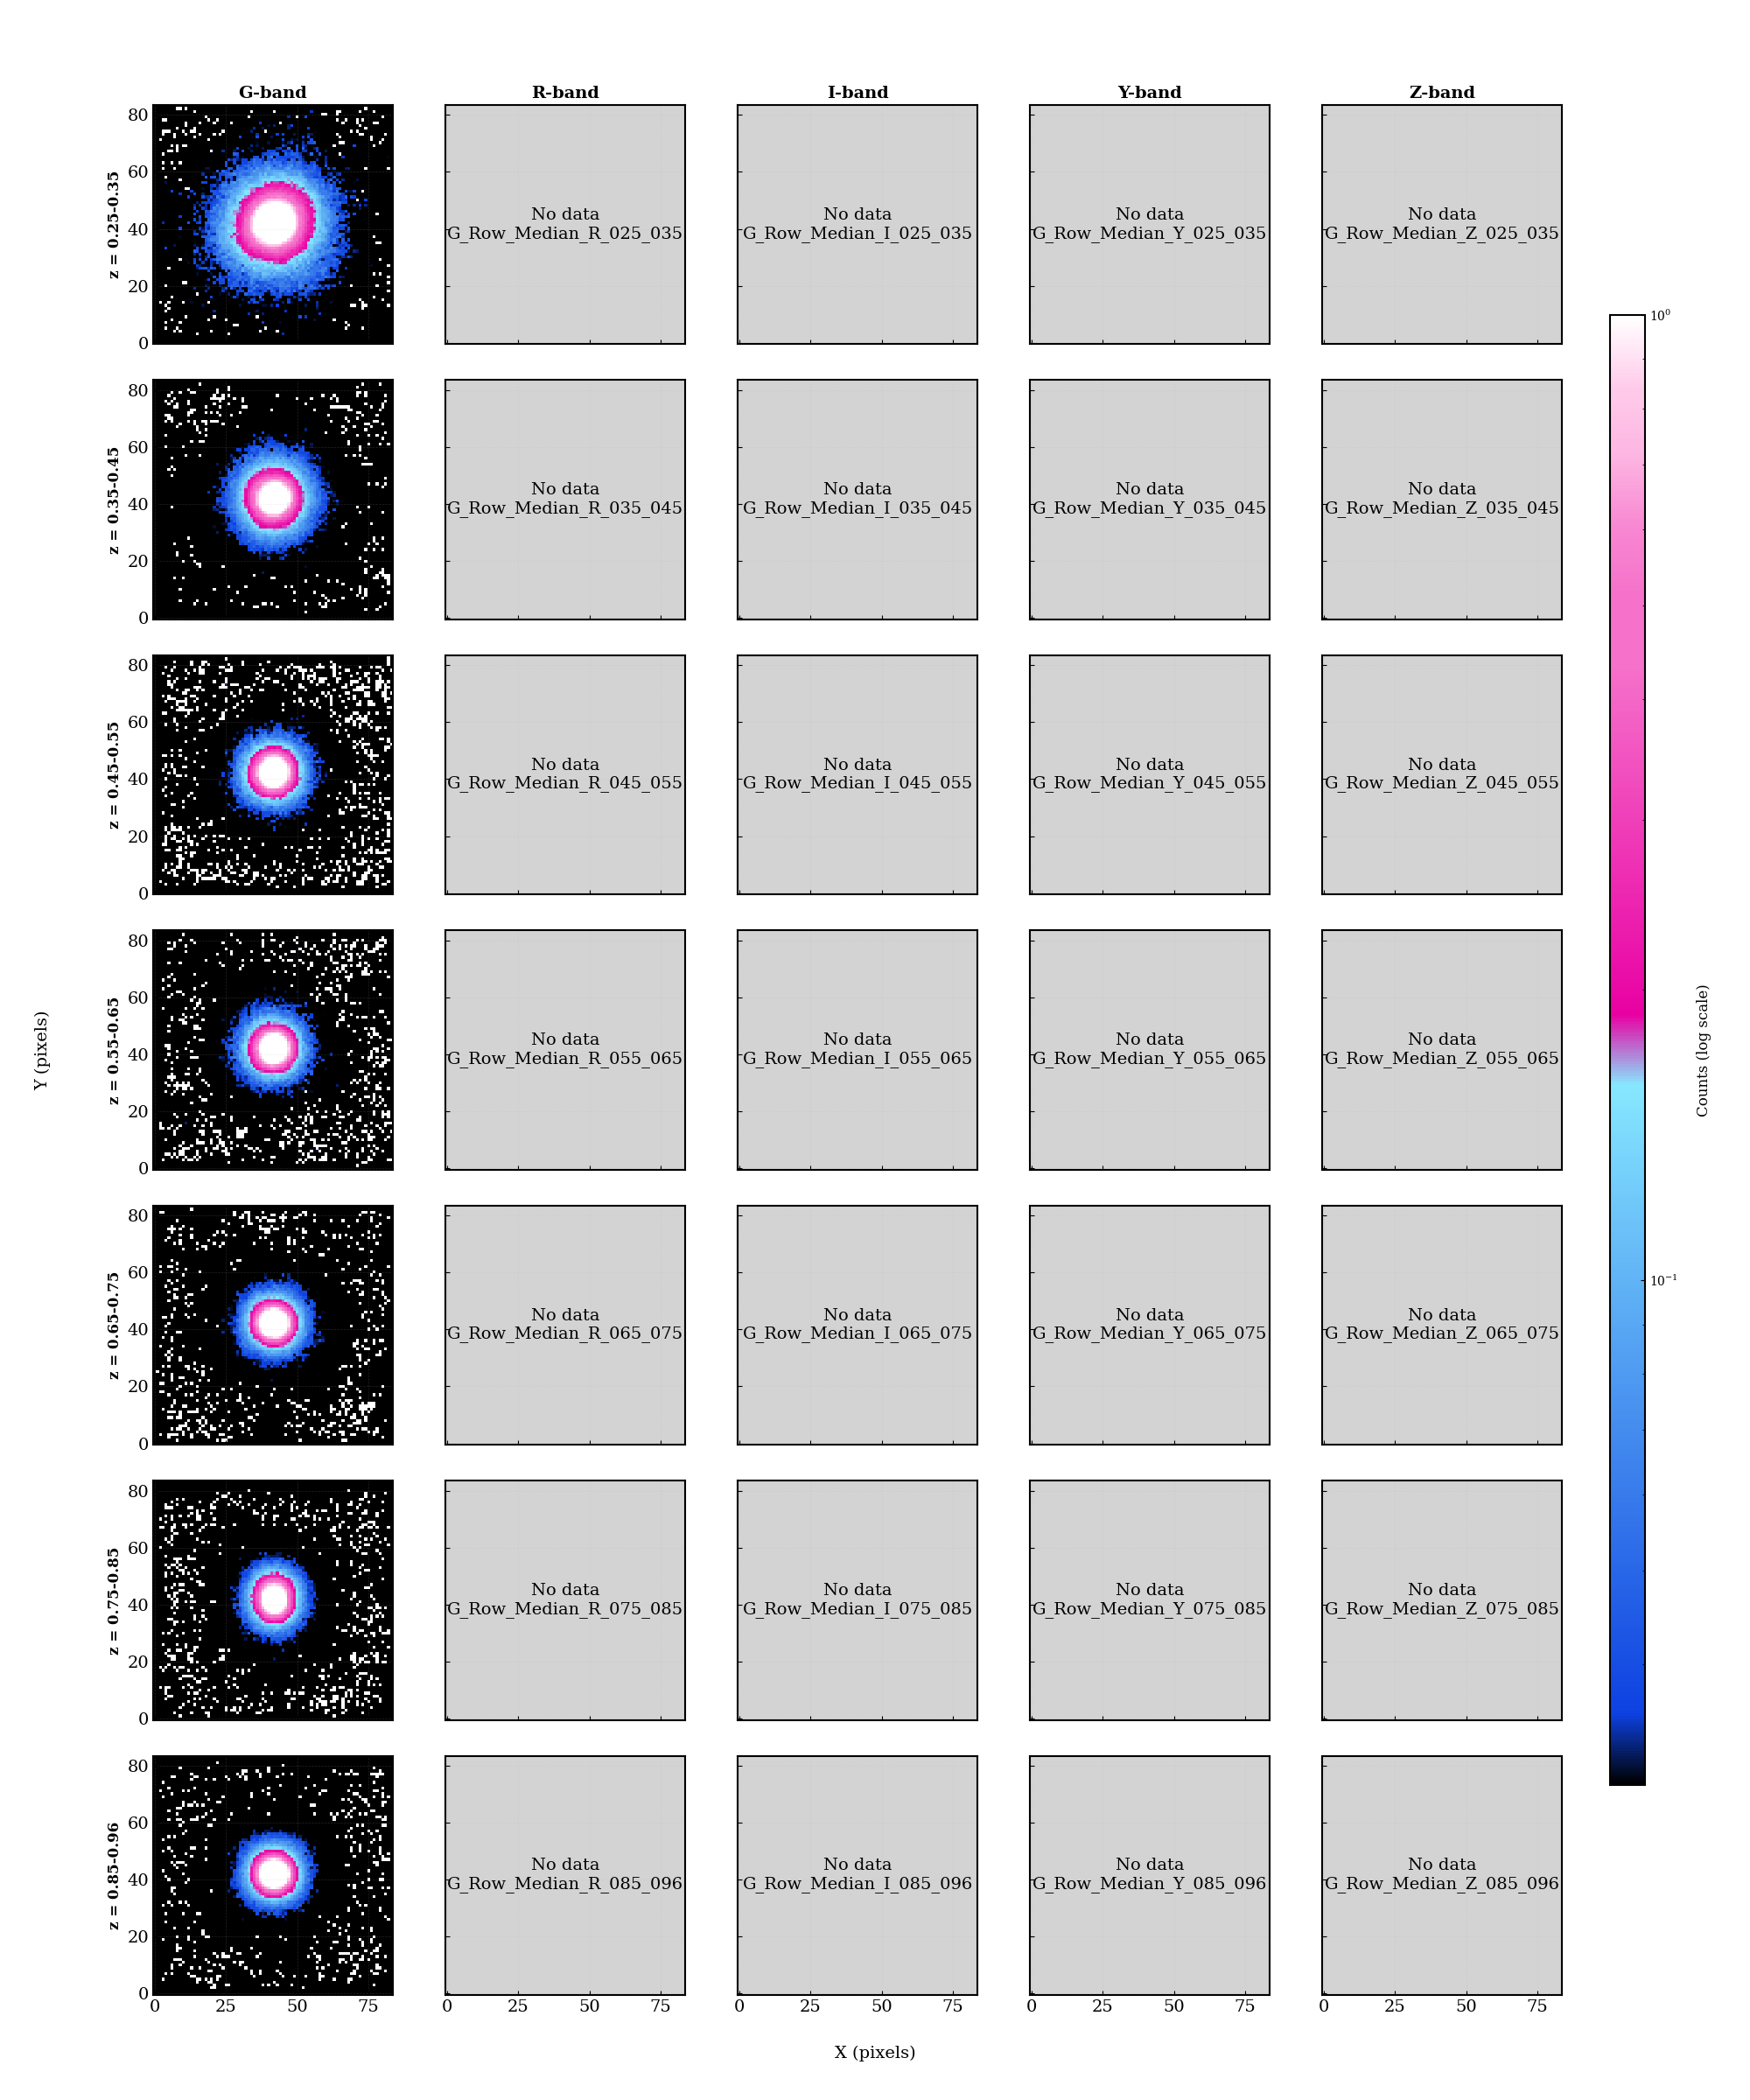

In [7]:
"""
I want to make a grid plot of all of the images for each filter and each redshift.
"""

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# Define the data structure
filters = ['G', 'R', 'I', 'Y', 'Z']
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']

# Create the figure with subplots
fig, axes = plt.subplots(len(redshift_bins), len(filters), 
                        figsize=(20, 24), 
                        sharex=True, sharey=True)

# Ensure axes is 2D array even for single row/column
if len(redshift_bins) == 1:
    axes = axes.reshape(1, -1)
elif len(filters) == 1:
    axes = axes.reshape(-1, 1)

# Plot each combination
for i, redshift_bin in enumerate(redshift_bins):
    for j, filter_name in enumerate(filters):
        ax = axes[i, j]
        
        # Get the data variable name 
        data_var_name = f'G_Row_Median_{filter_name}_{redshift_bin}'
        
        try:
            # Get the data (you'll need to replace this with your actual data access)
            # For now, using eval - in practice, you might want to use a dictionary
            data = eval(data_var_name)
            
            # Add small offset to avoid log(0)
            data_log = data + 0.0001
            
            # Create the image
            im = ax.imshow(data_log, origin='lower', cmap='New_Trans_Enhanced_c', 
                          norm=LogNorm(vmin=0.03, vmax=1.0))
            
            # Plot apertures if they exist for this combination
            aperture_var_name = f'Apertures_{redshift_bin}_Array'
            try:
                apertures = eval(aperture_var_name)
                for aperture in apertures:
                    aperture.plot(color='red', lw=1.5, alpha=0.8, ax=ax)
            except NameError:
                # If apertures don't exist for this combination, skip
                pass
                
        except NameError:
            # If data doesn't exist, create empty plot
            ax.text(0.5, 0.5, f'No data\n{data_var_name}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_facecolor('lightgray')
        
        # Set titles for top row (filter names)
        if i == 0:
            ax.set_title(f'{filter_name}-band', fontsize=14, fontweight='bold')
        
        # Set y-labels for leftmost column (redshift bins)
        if j == 0:
            ax.set_ylabel(f'z = {redshift_labels[i]}', fontsize=12, fontweight='bold')
        
        # Add subtle grid
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        ax.set_aspect('equal')

# Add overall labels
fig.text(0.5, 0.02, 'X (pixels)', ha='center', fontsize=14)
fig.text(0.02, 0.5, 'Y (pixels)', va='center', rotation=90, fontsize=14)

# Add a single colorbar for all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Counts (log scale)', fontsize=12, labelpad=15)
cbar.ax.tick_params(labelsize=10)

# Adjust layout
plt.subplots_adjust(left=0.08, right=0.9, top=0.95, bottom=0.05, 
                   hspace=0.15, wspace=0.1)

plt.show()


In [8]:
"""
I want to make a grid plot of the image for the closest filter to the l3000 continuum,
the MgII fit, and the stellar Bagpipes fit.
"""



'\nI want to make a grid plot of the image for the closest filter to the l3000 continuum,\nthe MgII fit, and the stellar Bagpipes fit.\n'

PDFPageCountError: Unable to get page count.
I/O Error: Couldn't open file '/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper/Redshift_025_035_n=1000_optimized_v3_tight_MCMC_Plotfixed_a_spectrum_fit.pdf': No such file or directory.


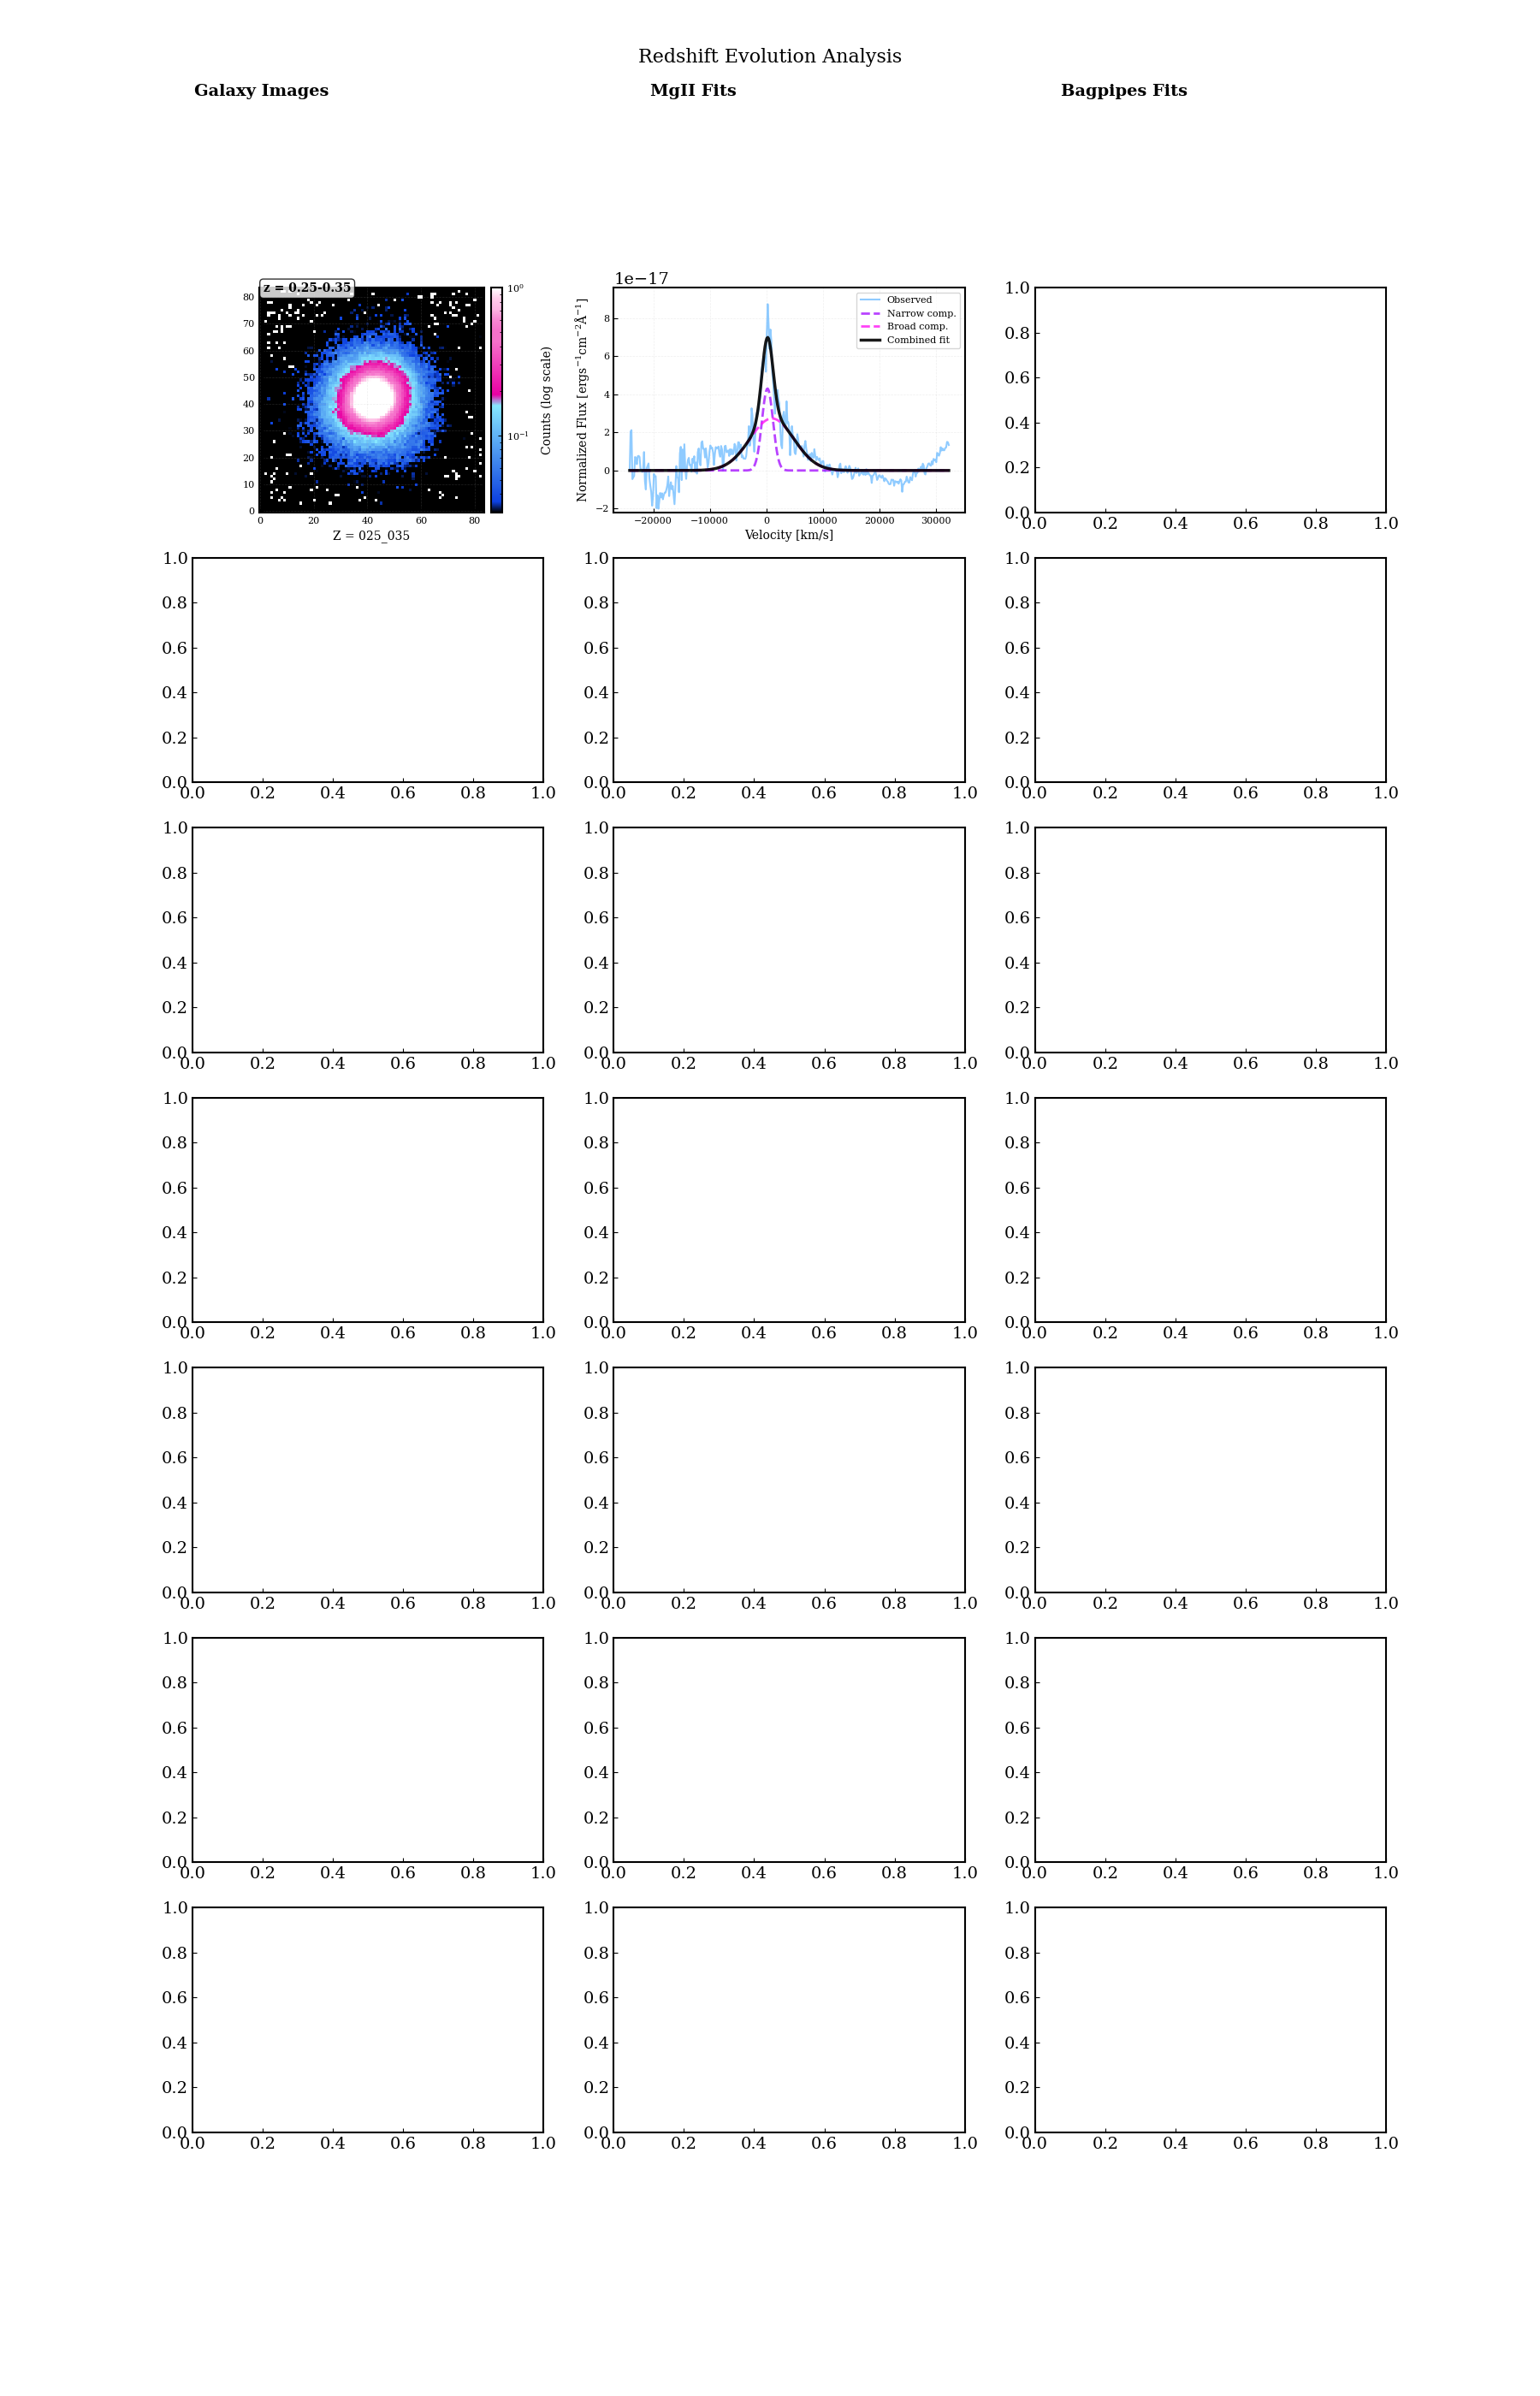

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# Define redshift bins
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']

# Create the grid plot
fig, axes = plt.subplots(7, 3, figsize=(18, 28))
fig.suptitle('Redshift Evolution Analysis', fontsize=16, y=0.98)

# Column headers
col_headers = ['Galaxy Images', 'MgII Fits', 'Bagpipes Fits']
for col, header in enumerate(col_headers):
    fig.text(0.17 + col * 0.28, 0.96, header, fontsize=14, ha='center', weight='bold')

for row, (redshift_bin, redshift_label) in enumerate(zip(redshift_bins, redshift_labels)):
    
    # Column 1: Galaxy Images
    ax1 = axes[row, 0]
    
    # Get the corresponding variables (you'll need to replace these with your actual variable names)
    try:
        # Replace with your actual variable names
        image_data = eval(f'G_Row_Median_G_{redshift_bin}')
        
        # Logarithmic scaling visualization (matching your style)
        data_log = image_data + 0.0001
        im1 = ax1.imshow(data_log, origin='lower', cmap='New_Trans_Enhanced_c', 
                        norm=LogNorm(vmin=0.03, vmax=1.0))

            
        # Create colorbar that matches plot height
        cbar1 = plt.colorbar(im1, ax=ax1, shrink=1.0, aspect=20, pad=0.02)
        cbar1.set_label('Counts (log scale)', fontsize=10, labelpad=10)
        cbar1.ax.tick_params(labelsize=8)
        
    except NameError:
        # Fallback if variables don't exist
        ax1.text(0.5, 0.5, f'Row_Median_G_{redshift_bin}\n(Variable not found)', 
                ha='center', va='center', transform=ax1.transAxes, fontsize=10)
    
    # Improve plot aesthetics
    ax1.set_xlabel(f'Z = {redshift_bin}', fontsize=10)
    ax1.tick_params(labelsize=8)
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    ax1.set_aspect('equal')
    
    # Add redshift label
    ax1.text(0.02, 0.98, f'z = {redshift_label}', transform=ax1.transAxes, 
            fontsize=10, weight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Column 2: MgII Fits
    ax2 = axes[row, 1]
    
    try:
        # Get MgII spectral data and fit parameters
        velocity = eval(f'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_{redshift_bin}')
        
        # Get Gaussian fit parameters - different naming for 025_035
        if redshift_bin == '025_035':
            # FeII_Removed naming convention for 025_035
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_{redshift_bin}')
            narrow_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            broad_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            best_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_{redshift_bin}')
        else:
            # Standard naming convention for other redshift bins
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_{redshift_bin}')
            narrow_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            broad_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            best_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_{redshift_bin}')

        # Plot the observed spectrum
        ax2.plot(velocity, flux, color = '#60B5FF', linewidth=1.5, alpha=0.7, label='Observed')
        
        ax2.plot(velocity, narrow_fit, '--', color='#a714ff', linewidth=2, 
                alpha=0.8, label='Narrow comp.')
        ax2.plot(velocity, broad_fit, '--', color='#ff14f5', linewidth=2, 
                alpha=0.8, label='Broad comp.')
        
        # Plot the combined best fit
        ax2.plot(velocity, best_fit, '-', color='black', linewidth=2.5, 
                alpha=0.9, label='Combined fit')
        
        # Formatting
        ax2.set_xlabel('Velocity [km/s]', fontsize=10)
        ax2.set_ylabel(r'Normalized Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', fontsize=10)
        ax2.tick_params(labelsize=8)
        ax2.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        ax2.legend(fontsize=8, loc='upper right')
        
        # Set reasonable y-limits
        ax2.set_ylim(np.min(flux) * 1.1, np.max([np.max(flux), np.max(best_fit)]) * 1.1)
        
    except NameError as e:
        ax2.text(0.5, 0.5, f'MgII Spectrum\n{redshift_bin}\n(Variables not found:\n{str(e)})', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=9)
        ax2.set_xlabel('Velocity [km/s]', fontsize=10)
        ax2.set_ylabel(r'Normalized Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', fontsize=10)
        ax2.tick_params(labelsize=8)
        ax2.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Column 3: Bagpipes Fits
    ax3 = axes[row, 2]
    
    try:
        # Option 1: Convert PDF to image using pdf2image (requires: pip install pdf2image)
        from pdf2image import convert_from_path
        bagpipes_file = f'/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper/Redshift_{redshift_bin}_n=1000_optimized_v3_tight_MCMC_Plotfixed_a_spectrum_fit.pdf'
        
        # Convert PDF first page to image
        pages = convert_from_path(bagpipes_file, first_page=1, last_page=1, dpi=150)
        if pages:
            pdf_image = np.array(pages[0])
            ax3.imshow(pdf_image)
            ax3.axis('off')  # Hide axes for cleaner look
        else:
            raise FileNotFoundError
            
    except (ImportError, FileNotFoundError):
        # Option 2: If pdf2image not available, try using PyMuPDF (fitz)
        try:
            import fitz  # PyMuPDF (pip install PyMuPDF)
            bagpipes_file = f'/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Redshift_{redshift_bin}_n=1000_optimized_v3_tight_MCMC_Plotfixed_a_spectrum_fit.pdf'
            
            # Open PDF and get first page
            doc = fitz.open(bagpipes_file)
            page = doc.load_page(0)  # First page
            pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))  # 2x zoom
            img_data = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
            
            if pix.n == 4:  # RGBA
                img_data = img_data[:, :, :3]  # Remove alpha channel
            
            ax3.imshow(img_data)
            ax3.axis('off')
            doc.close()
            
        except ImportError:
            # Fallback: Show file name with instructions
            ax3.text(0.5, 0.5, f'PDF: {bagpipes_file}\n\nInstall pdf2image or PyMuPDF\nto display PDF content:\n\npip install pdf2image\n# or\npip install PyMuPDF', 
                    ha='center', va='center', transform=ax3.transAxes, fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))
            
        except Exception as e:
            # File not found or other error
            ax3.text(0.5, 0.5, f'Error loading:\n{bagpipes_file}\n\n{str(e)}', 
                    ha='center', va='center', transform=ax3.transAxes, fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8))
    
    ax3.set_xlabel('Parameter', fontsize=10)
    ax3.set_ylabel('Value', fontsize=10)
    ax3.tick_params(labelsize=8)
    ax3.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, hspace=0.3, wspace=0.3)
plt.show()


In [ ]:
"""
I want to make a grid of the image for the closest filter to the l3000 continuum, the MgII fit, 
and the radial profile for the same filter.
"""

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# Define redshift bins
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']

# Create the grid plot
fig, axes = plt.subplots(7, 3, figsize=(18, 28))
fig.suptitle('Redshift Evolution Analysis', fontsize=16, y=0.98)

# Column headers
col_headers = ['Galaxy Images', 'MgII Fits', 'Bagpipes Fits']
for col, header in enumerate(col_headers):
    fig.text(0.17 + col * 0.28, 0.96, header, fontsize=14, ha='center', weight='bold')

for row, (redshift_bin, redshift_label) in enumerate(zip(redshift_bins, redshift_labels)):
    
    # Column 1: Galaxy Images (UNCHANGED)
    ax1 = axes[row, 0]
    
    # Get the corresponding variables (you'll need to replace these with your actual variable names)
    try:
        # Replace with your actual variable names
        image_data = eval(f'G_Row_Median_G_{redshift_bin}')
        
        # Logarithmic scaling visualization (matching your style)
        data_log = image_data + 0.0001
        im1 = ax1.imshow(data_log, origin='lower', cmap='New_Trans_Enhanced_c', 
                        norm=LogNorm(vmin=0.03, vmax=1.0))

            
        # Create colorbar that matches plot height
        cbar1 = plt.colorbar(im1, ax=ax1, shrink=1.0, aspect=20, pad=0.02)
        cbar1.set_label('Counts (log scale)', fontsize=10, labelpad=10)
        cbar1.ax.tick_params(labelsize=8)
        
    except NameError:
        # Fallback if variables don't exist
        ax1.text(0.5, 0.5, f'G_Row_Median_G_{redshift_bin}\n(Variable not found)', 
                ha='center', va='center', transform=ax1.transAxes, fontsize=10)
    
    # Improve plot aesthetics
    ax1.set_xlabel(f'Z = {redshift_bin}', fontsize=10)
    ax1.tick_params(labelsize=8)
    ax1.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    ax1.set_aspect('equal')
    
    # Add redshift label
    ax1.text(0.02, 0.98, f'z = {redshift_label}', transform=ax1.transAxes, 
            fontsize=10, weight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Column 2: MgII Fits (UNCHANGED)
    ax2 = axes[row, 1]
    
    try:
        # Get MgII spectral data and fit parameters
        velocity = eval(f'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_{redshift_bin}')
        
        # Get Gaussian fit parameters - different naming for 025_035
        if redshift_bin == '025_035':
            # FeII_Removed naming convention for 025_035
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_{redshift_bin}')
            narrow_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            broad_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            best_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_{redshift_bin}')
        else:
            # Standard naming convention for other redshift bins
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_{redshift_bin}')
            narrow_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            broad_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            best_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_{redshift_bin}')

        # Plot the observed spectrum
        ax2.plot(velocity, flux, color = '#60B5FF', linewidth=1.5, alpha=0.7, label='Observed')
        
        ax2.plot(velocity, narrow_fit, '--', color='#a714ff', linewidth=2, 
                alpha=0.8, label='Narrow comp.')
        ax2.plot(velocity, broad_fit, '--', color='#ff14f5', linewidth=2, 
                alpha=0.8, label='Broad comp.')
        
        # Plot the combined best fit
        ax2.plot(velocity, best_fit, '-', color='black', linewidth=2.5, 
                alpha=0.9, label='Combined fit')
        
        # Formatting
        ax2.set_xlabel('Velocity [km/s]', fontsize=10)
        ax2.set_ylabel(r'Normalized Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', fontsize=10)
        ax2.tick_params(labelsize=8)
        ax2.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        ax2.legend(fontsize=8, loc='upper right')
        
        # Set reasonable y-limits
        ax2.set_ylim(np.min(flux) * 1.1, np.max([np.max(flux), np.max(best_fit)]) * 1.1)
        
    except NameError as e:
        ax2.text(0.5, 0.5, f'MgII Spectrum\n{redshift_bin}\n(Variables not found:\n{str(e)})', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=9)
        ax2.set_xlabel('Velocity [km/s]', fontsize=10)
        ax2.set_ylabel(r'Normalized Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', fontsize=10)
        ax2.tick_params(labelsize=8)
        ax2.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Column 3: AGN Model Fits (Same as document 3)
    ax3 = axes[row, 2]
    
    try:
        # Get the corresponding variables for this redshift bin
        x_data_var = f'G_x_data_SersicNOne_GaussianFixedSigma_{redshift_bin}'
        y_data_var = f'G_y_data_SersicNOne_GaussianFixedSigma_{redshift_bin}'
        x_new_var = f'G_x_new_SersicNOne_GaussianFixedSigma_{redshift_bin}'
        yy_new_var = f'G_yy_new_SersicNOne_GaussianFixedSigma_{redshift_bin}'
        yy_new_err_var = f'G_yy_new_err_SersicNOne_GaussianFixedSigma_{redshift_bin}'
        Popt_var = f'G_Popt_SersicNOne_GaussianFixedSigma_{redshift_bin}'
        
        x_data = eval(x_data_var)
        y_data = eval(y_data_var)
        x_new = eval(x_new_var)
        yy_new = eval(yy_new_var)
        yy_new_err = eval(yy_new_err_var)
        Popt = eval(Popt_var)
        
        # Plot observed data (step plot)
        ax3.step(x_data, y_data, color="black", linewidth=2.0, where="mid", zorder=1, label="Observed Data", linestyle='-')
        
        # Plot smoothed data
        ax3.plot(x_new, yy_new, color="#309898", label="Smoothed Data", linewidth=4.0, zorder=5, linestyle=':')
        
        # Fill between for error bounds
        ax3.fill_between(x_new, yy_new - 3*yy_new_err, yy_new + 3*yy_new_err, color='#FFC1DA', alpha=0.3)

        # Get the PSF for this specific filter
        psf_var = f'PSF_{filter_name}'
        psf_value = globals().get(psf_var)
        
        # Combined model fit
        ax3.plot(x_new, Total_Model_BG(x_new, *Popt[:5], psf_value), color="#DB3EB1", linewidth=2.0, label="Combined Model Fit", zorder=10, linestyle='-')
        
        # Gaussian component
        ax3.plot(x_new, Gaussian_Component_BG(x_new, *Popt[3:5], psf_value), color="#1D5799", linewidth=2.0, label="Gauss Component", zorder=10, linestyle='--')
        
        # Sersic component
        ax3.plot(x_new, Sersic_Convolved_Model_BG(x_new, *Popt[:4], psf_value), color="#9467BD", linewidth=2.0, label="Sersic Component", zorder=10, linestyle='-.')
        
        # Add redshift text
        ax3.text(0.02, 0.96, f"Redshift: {redshift_label}", transform=ax3.transAxes,
                fontsize=8, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black'))
        
        # Legend
        ax3.legend(loc='upper right', fontsize=6, frameon=True, fancybox=True, shadow=True, borderpad=0.5, 
                  edgecolor='black', facecolor='w', handlelength=2.0)
        
        # Formatting
        ax3.set_xlabel("Radius from center [arcsecond]", fontsize=10)
        ax3.set_ylabel("Average Counts / Second", fontsize=10)
        ax3.tick_params(labelsize=8)
        ax3.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        
        # Make axes thicker
        ax3.spines['top'].set_linewidth(1.5)
        ax3.spines['right'].set_linewidth(1.5)
        ax3.spines['left'].set_linewidth(1.5)
        ax3.spines['bottom'].set_linewidth(1.5)
        ax3.tick_params(axis='both', which='major', width=1)
        
    except (NameError, TypeError) as e:
        # Fallback if variables don't exist
        ax3.text(0.5, 0.5, f'AGN Model Fit\n{redshift_bin}\n(Variables not found:\n{str(e)[:50]}...)', 
                ha='center', va='center', transform=ax3.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8))
        ax3.set_xlabel("Radius from center [arcsecond]", fontsize=10)
        ax3.set_ylabel("Average Counts / Second", fontsize=10)
        ax3.tick_params(labelsize=8)
        ax3.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.94, hspace=0.3, wspace=0.3)
plt.show()


In [ ]:
"""
MAKE THE ABOVE PLOT BUT THE THIRD PLOT FOR ALL FILTERS WITH THE IMAGE AS AN INSET.
I want the corner plot with the Bagpipes fit inset on it.
"""

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# Set publication-quality matplotlib parameters - adjusted for 10x10 figure
plt.rcParams.update({
    'font.size': 6,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.linewidth': 0.8,
    'axes.labelsize': 7,
    'xtick.labelsize': 5,
    'ytick.labelsize': 5,
    'legend.fontsize': 5,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'text.usetex': False,  # Set to True if you have LaTeX installed
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.3
})

# Define redshift bins and filters
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = ['0.25–0.35', '0.35–0.45', '0.45–0.55', '0.55–0.65', '0.65–0.75', '0.75–0.85', '0.85–0.96']
filters = ['G', 'R', 'I', 'Y', 'Z']

# Original color scheme
colors = {
    'z_025_035': "#a714ff",   # Purple (deep/cool)
    'z_035_045': "#ff14f5",   # Pink
    'z_045_055': "#14D8FF",   # Teal
    'z_055_065': "#60B5FF",   # Blue
    'z_065_075': "#00FF9C",   # Green
    'z_075_085': "#ffbb14",   # Orange
    'z_085_096': "#FF5757",   # Red (warm)
    'reference_lines': "black",
    'component_1': "black",        # Changed to black for Gaussian
    'component_2': "black"         # Changed to black for Sersic
}

# Create the figure with 10x10 size
fig, axes = plt.subplots(7, 5, figsize=(10, 10))

# Column headers for filters using ax.set_title
for i, filter_name in enumerate(filters):
    axes[0, i].set_title(f'{filter_name}-band', fontsize=8, fontweight='bold')
            
# Calculate row positions to align with subplot centers - using actual subplot positions
for row, (redshift_bin, redshift_label) in enumerate(zip(redshift_bins, redshift_labels)):
    # Get the actual position of the subplot in this row
    ax_pos = axes[row, 0].get_position()
    row_center = ax_pos.y0 + ax_pos.height / 2
    #fig.text(0.955, row_center, f'$z$ = {redshift_label}', fontsize=11, ha='center', va='center', 
    #         weight='bold', rotation=90)
    
    # Get color for this redshift bin
    redshift_color_key = f'z_{redshift_bin}'
    primary_color = colors.get(redshift_color_key, "#0FA3B1")
    
    for col, filter_name in enumerate(filters):
        ax = axes[row, col]
        
        try:
            # Get the corresponding variables for this redshift bin and filter
            x_data_var = f'{filter_name}_x_data_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            y_data_var = f'{filter_name}_y_data_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            x_new_var = f'{filter_name}_x_new_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            yy_new_var = f'{filter_name}_yy_new_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            yy_new_err_var = f'{filter_name}_yy_new_err_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            Popt_var = f'{filter_name}_Popt_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            
            # Safer variable access with error handling
            x_data = globals().get(x_data_var)
            y_data = globals().get(y_data_var)
            x_new = globals().get(x_new_var)
            yy_new = globals().get(yy_new_var)
            yy_new_err = globals().get(yy_new_err_var)
            Popt = globals().get(Popt_var)
            
            # Check if all required variables exist and are not None
            if any(var is None for var in [x_data, y_data, x_new, yy_new, yy_new_err, Popt]):
                raise NameError("Required variables not found")

            # Get the PSF for this specific filter
            psf_var = f'PSF_{filter_name}'
            psf_value = globals().get(psf_var)
            
            # Plot with improved styling
            # Error region first (lowest z-order)
            ax.fill_between(x_new, yy_new - 3*yy_new_err, yy_new + 3*yy_new_err, 
                           color=primary_color, alpha=0.15, zorder=1, label='3σ uncertainty')
            
            # Observed data points (steps)
            ax.step(x_data, y_data, color=colors['reference_lines'], linewidth=1.2, 
                   where="mid", zorder=4, label="Observed data", linestyle='-', alpha=0.8)
            
            # Model components with black color
            ax.plot(x_new, Sersic_Convolved_Model_BG(x_new, *Popt[:4], psf_value), 
                   color=colors['component_2'], linewidth=1.0, label="Sersic component", 
                   zorder=5, linestyle='--', alpha=0.9)
            
            ax.plot(x_new, Gaussian_Component_BG(x_new, *Popt[3:5], psf_value), 
                   color=colors['component_1'], linewidth=1.0, label="Gaussian component", 
                   zorder=6, linestyle=':', alpha=0.9)
            
            # Combined model fit with rainbow color for each redshift
            ax.plot(x_new, Total_Model_BG(x_new, *Popt[:5], psf_value), color=primary_color, 
                   linewidth=1.8, label="Total model", zorder=7, linestyle='-', alpha=1.0)
            
            # Remove individual subplot legends since we have a global one
            # (Legend code removed)
            
            # Axis formatting - only bottom row gets x-axis label and tick labels
            if row == 6:  # Bottom row (row 6 is the last row)
                ax.set_xlabel("Radius (arcsec)", fontsize=6)
            else:
                ax.set_xticklabels([])  # Remove x-axis tick labels for all other rows
            
            if col == 0:  # Only leftmost column gets y-axis label
                ax.set_ylabel(f"$\\mathbf{{Z = {redshift_label}}}$\n$\\langle$Counts$\\rangle$ / s", fontsize=6)
            
            # Improved grid and spines
            ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='gray')
            ax.set_axisbelow(True)
            
            for spine_name, spine in ax.spines.items():
                spine.set_linewidth(0.8)
                spine.set_color('#4A5568')
            
            ax.tick_params(axis='both', which='major', width=0.7, length=3, color='#4A5568')
            ax.tick_params(axis='both', which='minor', width=0.4, length=1.5, color='#4A5568')

            ax.set_xlim(0,5)
            
            # Set reasonable axis limits if data exists
            if len(x_data) > 0 and len(y_data) > 0:
                y_min, y_max = min(y_data), max(y_data)
                ax.set_ylim(y_min * 0.8, y_max * 1.1)
            
            # Add larger, better-positioned galaxy image inset
            try:
                image_data_var = f'{filter_name}_Row_Median_{filter_name}_{redshift_bin}'
                image_data = globals().get(image_data_var)
                
                if image_data is None:
                    raise NameError("Image data not found")
                
                # Create larger inset in upper right
                inset_ax = inset_axes(ax, width="55%", height="55%", 
                                    bbox_to_anchor=(0.08, 0.015, 1, 1), bbox_transform=ax.transAxes)
                
                # Enhanced image display
                data_log = image_data + 0.0001  # Avoid log(0)
                im_inset = inset_ax.imshow(data_log, origin='lower', cmap='New_Trans_Enhanced_c', 
                                         norm=LogNorm(vmin=0.03, vmax=1.0))

                # Clean inset appearance
                inset_ax.set_xticks([])
                inset_ax.set_yticks([])
                inset_ax.set_aspect('equal')
                
                # Add scale indicator if image size is available
                if hasattr(image_data, 'shape'):
                    # Assume typical HSC pixel scale of ~0.17"/pixel
                    scale_text = "2″"
                    inset_ax.text(0.95, 0.05, scale_text, transform=inset_ax.transAxes,
                                color='black', fontsize=4, ha='right', va='bottom',
                                bbox=dict(boxstyle='square', facecolor='#00FF38', alpha=1.0, edgecolor="None"))
                
            except (NameError, ValueError, AttributeError):
                # Professional placeholder for missing data
                inset_ax = inset_axes(ax, width="50%", height="50%", loc='upper right', 
                                    bbox_to_anchor=(0.0, 0.02, 1, 1), bbox_transform=ax.transAxes)
                inset_ax.add_patch(plt.Rectangle((0, 0), 1, 1, facecolor='#F7FAFC', 
                                               edgecolor='#CBD5E0', transform=inset_ax.transAxes))
                inset_ax.text(0.5, 0.5, 'No image\navailable', ha='center', va='center', 
                            transform=inset_ax.transAxes, fontsize=5, color='#718096',
                            style='italic')
                inset_ax.set_xlim(0, 1)
                inset_ax.set_ylim(0, 1)
                inset_ax.set_xticks([])
                inset_ax.set_yticks([])
                
        except (NameError, TypeError, ValueError) as e:
            # Clean error display for missing variables
            ax.text(0.5, 0.5, f'Data not available\nfor {filter_name}-band\nz = {redshift_label}', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=5,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FED7D7', 
                            edgecolor='#FC8181', alpha=0.8),
                    color='#C53030')
            if row == 6:  # Bottom row gets x-axis label
                ax.set_xlabel("Radius (arcsec)", fontsize=6)
            else:
                ax.set_xticklabels([])  # Remove x-axis tick labels for all other rows
            
            if col == 0:
                ax.set_ylabel("$\\langle$Counts$\\rangle$ / s", fontsize=6)
            
            # Maintain consistent appearance
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)
                spine.set_color('#4A5568')
            ax.grid(True, alpha=0.25)

# Final layout adjustments for publication
plt.tight_layout()
plt.subplots_adjust(top=0.91, right=0.93, bottom=0.12, left=0.07, hspace=0.1, wspace=0.25)

# Create a custom stepped line for the legend
class SteppedLine:
    def __init__(self, color, linewidth, alpha=1.0):
        self.color = color
        self.linewidth = linewidth
        self.alpha = alpha
    
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        
        # Create stepped line points
        x_points = [x0, x0 + width/4, x0 + width/4, x0 + 2*width/4, x0 + 2*width/4, 
                   x0 + 3*width/4, x0 + 3*width/4, x0 + width]
        y_points = [y0 + height/2, y0 + height/2, y0 + 3*height/4, y0 + 3*height/4, 
                   y0 + height/4, y0 + height/4, y0 + height/2, y0 + height/2]
        
        line = plt.Line2D(x_points, y_points, color=self.color, 
                         linewidth=self.linewidth, alpha=self.alpha)
        handlebox.add_artist(line)
        return line

# Create rainbow gradient line for total model legend
from matplotlib.colors import LinearSegmentedColormap
rainbow_colors = ['#a714ff', '#ff14f5', '#14D8FF', '#60B5FF', '#00FF9C', '#ffbb14', '#FF5757']
rainbow_cmap = LinearSegmentedColormap.from_list("rainbow", rainbow_colors)

# Create rainbow gradient rectangle for 3σ uncertainty legend
class RainbowRectangle:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        
        # Create multiple colored segments for the rectangle
        n_segments = 20
        segment_width = width / n_segments
        
        for i in range(n_segments):
            color = rainbow_cmap(i / n_segments)
            rect = plt.Rectangle((x0 + i * segment_width, y0), segment_width, height, 
                               facecolor=color, alpha=0.15, edgecolor='none')
            handlebox.add_artist(rect)
        return rect

class RainbowLine:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        
        # Create multiple colored segments
        n_segments = 20
        x_points = np.linspace(x0, x0 + width, n_segments + 1)
        y_center = y0 + height/2
        
        for i in range(n_segments):
            color = rainbow_cmap(i / n_segments)
            line = plt.Line2D([x_points[i], x_points[i+1]], [y_center, y_center], 
                             color=color, linewidth=2.5)
            handlebox.add_artist(line)
        return line

# Create legend elements with custom handlers
legend_elements = [
    (plt.Line2D([0], [0], color='black', linewidth=1.8), SteppedLine('black', 1.8)),
    (plt.Line2D([0], [0], color='gray', linewidth=2.5), RainbowLine()),
    plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='Sersic component'),
    plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label='Gaussian component'),
    (plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.15), RainbowRectangle())
]

# Separate handles and labels for custom legend
handles = []
labels = ['Observed data', 'Total model', 'Sersic component', 'Gaussian component', '3σ uncertainty']
handler_map = {}

for i, (element, label) in enumerate(zip(legend_elements, labels)):
    if i == 0:  # Observed data with stepped line
        handles.append(element[0])
        handler_map[element[0]] = element[1]
    elif i == 1:  # Total model with rainbow line
        handles.append(element[0])
        handler_map[element[0]] = element[1]
    elif i == 4:  # 3σ uncertainty with rainbow rectangle
        handles.append(element[0])
        handler_map[element[0]] = element[1]
    else:  # Regular elements
        handles.append(element)

# Add legend at bottom center with custom handler
legend = fig.legend(handles=handles, labels=labels, loc='lower center', ncol=5, fontsize=6, 
           frameon=True, fancybox=False, shadow=False, borderpad=0.3,
           edgecolor='black', facecolor='white', framealpha=0.95,
           bbox_to_anchor=(0.5, 0.045), handlelength=1.5, handler_map=handler_map)

# Add colorbar for galaxy images on the right side
# Position it on the right side of the figure
cbar_ax = fig.add_axes([0.94, 0.24, 0.01, 0.548])  # [left, bottom, width, height]
norm = LogNorm(vmin=0.03, vmax=1.0)
sm = plt.cm.ScalarMappable(cmap='New_Trans_Enhanced_c', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Counts (log scale)', fontsize=14, labelpad=4, rotation=90)
cbar.ax.tick_params(labelsize=6)
# Add multiple labels across the colorbar range
cbar.set_ticks([0.03, 0.1, 0.3, 0.6, 1.0])
cbar.set_ticklabels(['0.03', '0.1', '0.3', '0.6', '1.0'])


plt.savefig('/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Radial_Profile_Inset_Image_fits_3x3.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
"""
I want to make a grid plot of all of the radial fits for all of the filters and all of the redshifts.
"""

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib as mpl

# Set publication-quality matplotlib parameters - adjusted for 10x10 figure
plt.rcParams.update({
    'font.size': 6,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.linewidth': 0.8,
    'axes.labelsize': 7,
    'xtick.labelsize': 5,
    'ytick.labelsize': 5,
    'legend.fontsize': 5,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'text.usetex': False,  # Set to True if you have LaTeX installed
    'axes.grid': True,
    'grid.alpha': 0.4,      # Increased from 0.3 for better visibility
    'grid.linewidth': 0.5   # Slightly thicker for better visibility
})

# Define redshift bins and filters
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = ['0.25–0.35', '0.35–0.45', '0.45–0.55', '0.55–0.65', '0.65–0.75', '0.75–0.85', '0.85–0.96']
filters = ['G', 'R', 'I', 'Y', 'Z']

# Original color scheme
colors = {
    'z_025_035': "#a714ff",   # Purple (deep/cool)
    'z_035_045': "#ff14f5",   # Pink
    'z_045_055': "#14D8FF",   # Teal
    'z_055_065': "#60B5FF",   # Blue
    'z_065_075': "#00FF9C",   # Green
    'z_075_085': "#ffbb14",   # Orange
    'z_085_096': "#FF5757",   # Red (warm)
    'reference_lines': "black",
    'component_1': "black",        # Changed to black for Gaussian
    'component_2': "black"         # Changed to black for Sersic
}

# Create the figure with 10x10 size
fig, axes = plt.subplots(7, 5, figsize=(10, 10))

# Column headers for filters using ax.set_title
for i, filter_name in enumerate(filters):
    axes[0, i].set_title(f'{filter_name}-band', fontsize=8, fontweight='bold')
            
# Calculate row positions to align with subplot centers - using actual subplot positions
for row, (redshift_bin, redshift_label) in enumerate(zip(redshift_bins, redshift_labels)):
    # Get the actual position of the subplot in this row
    ax_pos = axes[row, 0].get_position()
    row_center = ax_pos.y0 + ax_pos.height / 2
    #fig.text(0.955, row_center, f'$z$ = {redshift_label}', fontsize=11, ha='center', va='center', 
    #         weight='bold', rotation=90)
    
    # Get color for this redshift bin
    redshift_color_key = f'z_{redshift_bin}'
    primary_color = colors.get(redshift_color_key, "#0FA3B1")
    
    for col, filter_name in enumerate(filters):
        ax = axes[row, col]
        
        try:
            # Get the corresponding variables for this redshift bin and filter
            x_data_var = f'{filter_name}_x_data_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            y_data_var = f'{filter_name}_y_data_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            x_new_var = f'{filter_name}_x_new_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            yy_new_var = f'{filter_name}_yy_new_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            yy_new_err_var = f'{filter_name}_yy_new_err_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            Popt_var = f'{filter_name}_Popt_SersicNOne_GaussianFixedSigma_{redshift_bin}'
            
            # Safer variable access with error handling
            x_data = globals().get(x_data_var)
            y_data = globals().get(y_data_var)
            x_new = globals().get(x_new_var)
            yy_new = globals().get(yy_new_var)
            yy_new_err = globals().get(yy_new_err_var)
            Popt = globals().get(Popt_var)
            
            # Check if all required variables exist and are not None
            if any(var is None for var in [x_data, y_data, x_new, yy_new, yy_new_err, Popt]):
                raise NameError("Required variables not found")
            
            # Plot with improved styling
            # Error region first (lowest z-order)
            ax.fill_between(x_new, yy_new - 3*yy_new_err, yy_new + 3*yy_new_err, 
                           color=primary_color, alpha=0.15, zorder=1, label='3σ uncertainty')
            
            # Observed data points (steps)
            ax.step(x_data, y_data, color=colors['reference_lines'], linewidth=1.2, 
                   where="mid", zorder=4, label="Observed data", linestyle='-', alpha=0.8)
            
            # Get the PSF for this specific filter
            psf_var = f'PSF_{filter_name}'
            psf_value = globals().get(psf_var)
            
            # Model components with black color
            ax.plot(x_new, Sersic_Convolved_Model_BG(x_new, *Popt[:4], psf_value), 
                   color=colors['component_2'], linewidth=1.0, label="Sersic component", 
                   zorder=5, linestyle='--', alpha=0.9)
            
            ax.plot(x_new, Gaussian_Component_BG(x_new, *Popt[3:5], psf_value), 
                   color=colors['component_1'], linewidth=1.0, label="Gaussian component", 
                   zorder=6, linestyle=':', alpha=0.9)
            
            # Combined model fit with rainbow color for each redshift
            ax.plot(x_new, Total_Model_BG(x_new, *Popt[:5], psf_value), color=primary_color, 
                   linewidth=1.8, label="Total model", zorder=7, linestyle='-', alpha=1.0)
            
            # Axis formatting - only bottom row gets x-axis label and tick labels
            if row == 6:  # Bottom row (row 6 is the last row)
                ax.set_xlabel("Radius (arcsec)", fontsize=6)
            else:
                ax.set_xticklabels([])  # Remove x-axis tick labels for all other rows
            
            if col == 0:  # Only leftmost column gets y-axis label
                ax.set_ylabel(f"$\\mathbf{{Z = {redshift_label}}}$\n$\\langle$Counts$\\rangle$ / s", fontsize=6)
            
            # REMOVE GRID FROM MAIN PLOT
            ax.grid(False)
            
            # Better spine styling
            for spine_name, spine in ax.spines.items():
                spine.set_linewidth(0.8)
                spine.set_color('#333333')  # Darker for better contrast
            
            ax.tick_params(axis='both', which='major', width=0.7, length=3, color='#333333')
            ax.tick_params(axis='both', which='minor', width=0.4, length=1.5, color='#333333')

            ax.set_ylim(-1.5, max(y_data)+4.5, auto=False)

            # ADD IMPROVED ZOOMED INSET
            from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
            axins = inset_axes(ax, width="60%", height="40%", loc='upper right', 
                                    bbox_to_anchor=(0.0, -0.02, 1, 1), bbox_transform=ax.transAxes) 

            axins.fill_between(x_new, yy_new - 3*yy_new_err, yy_new + 3*yy_new_err, 
                              color=primary_color, alpha=0.15, zorder=1, label='3σ uncertainty')
            axins.step(x_data, y_data, color=colors['reference_lines'], linewidth=1.2, 
                      where="mid", zorder=4, label="Observed data", linestyle='-', alpha=1.0)
            axins.plot(x_new, Sersic_Convolved_Model_BG(x_new, *Popt[:4], psf_value), 
                      color=colors['component_2'], linewidth=1.0, label="Sersic component", 
                      zorder=5, linestyle='--', alpha=1.0)
            axins.plot(x_new, Gaussian_Component_BG(x_new, *Popt[3:5], psf_value), 
                      color=colors['component_1'], linewidth=1.0, label="Gaussian component", 
                      zorder=6, linestyle=':', alpha=1.0)
            axins.plot(x_new, Total_Model_BG(x_new, *Popt[:5], psf_value), color=primary_color, 
                      linewidth=1.8, label="Total model", zorder=7, linestyle='-', alpha=1.0)
            
            # Set zoom region
            axins.set_xlim(-0.2, 3, auto=False)
            axins.set_ylim(-1.0, max(y_data)+4, auto=False)

            # ADD GRID TO INSET - more visible for detailed view with minor grid
            axins.grid(True, alpha=0.4, linestyle='-', linewidth=0.3, color='#666666', which='major')
            axins.grid(True, alpha=0.2, linestyle='-', linewidth=0.15, color='#666666', which='minor')
            axins.set_axisbelow(True)
            
            # Enable minor ticks for the grid
            axins.minorticks_on()
            
            # IMPROVED INSET STYLING
            for spine_name, spine in axins.spines.items():
                spine.set_linewidth(0.6)
                spine.set_color('#333333')
        
            # BETTER TICK FORMATTING FOR INSETS
            # Fewer ticks and larger labels
            axins.tick_params(axis='both', which='major', direction="in", 
                             width=0.5, length=2.5, color='#333333', 
                             labelsize=4)  # Larger font for inset
            axins.tick_params(axis='both', which='minor', direction="in", 
                             width=0.3, length=1.2, color='#333333')
            
            # Set specific tick locations for cleaner look
            axins.set_xticks([0, 1, 2, 3])
            # Set simple, readable y-axis ticks with fewer ticks for less crowding
            y_min, y_max = axins.get_ylim()
            if y_max <= 3:
                # For very small ranges, use 1 increments
                y_ticks = np.arange(0, int(y_max) + 1, 1)
            elif y_max <= 8:
                # For small-medium ranges, use 2 increments
                y_ticks = np.arange(0, int(y_max) + 2, 2)
            elif y_max <= 15:
                # For medium ranges, use 5 increments
                y_ticks = np.arange(0, int(y_max) + 5, 5)
            else:
                # For large ranges, use 10 increments
                y_ticks = np.arange(0, int(y_max) + 10, 10)
            
            # Filter ticks to only show those within the actual range and limit to max 4 ticks
            y_ticks = y_ticks[(y_ticks >= y_min) & (y_ticks <= y_max)]
            if len(y_ticks) > 4:
                # If still too many, take every other tick
                y_ticks = y_ticks[::2]
            axins.set_yticks(y_ticks)

            # SOLID CONNECTION LINES - behind everything in inset
            # Use mark_inset with solid styling and very low zorder
            mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="#666666", 
                      linewidth=0.4, alpha=0.6, zorder=-10, linestyle='-')
            
        except (NameError, TypeError, ValueError) as e:
            # Clean error display for missing variables
            ax.text(0.5, 0.5, f'Data not available\nfor {filter_name}-band\nz = {redshift_label}', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=5,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FED7D7', 
                            edgecolor='#FC8181', alpha=0.8),
                    color='#C53030')
            if row == 6:  # Bottom row gets x-axis label
                ax.set_xlabel("Radius (arcsec)", fontsize=6)
            else:
                ax.set_xticklabels([])  # Remove x-axis tick labels for all other rows
            
            if col == 0:
                ax.set_ylabel("$\\langle$Counts$\\rangle$ / s", fontsize=6)
            
            # Maintain consistent appearance
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)
                spine.set_color('#4A5568')
            ax.grid(False)  # No grid for error cases either

# Final layout adjustments for publication
plt.tight_layout()
plt.subplots_adjust(top=0.91, right=0.93, bottom=0.12, left=0.07, hspace=0.1, wspace=0.25)

# Create a custom stepped line for the legend
class SteppedLine:
    def __init__(self, color, linewidth, alpha=1.0):
        self.color = color
        self.linewidth = linewidth
        self.alpha = alpha
    
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        
        # Create stepped line points
        x_points = [x0, x0 + width/4, x0 + width/4, x0 + 2*width/4, x0 + 2*width/4, 
                   x0 + 3*width/4, x0 + 3*width/4, x0 + width]
        y_points = [y0 + height/2, y0 + height/2, y0 + 3*height/4, y0 + 3*height/4, 
                   y0 + height/4, y0 + height/4, y0 + height/2, y0 + height/2]
        
        line = plt.Line2D(x_points, y_points, color=self.color, 
                         linewidth=self.linewidth, alpha=self.alpha)
        handlebox.add_artist(line)
        return line

# Create rainbow gradient line for total model legend
from matplotlib.colors import LinearSegmentedColormap
rainbow_colors = ['#a714ff', '#ff14f5', '#14D8FF', '#60B5FF', '#00FF9C', '#ffbb14', '#FF5757']
rainbow_cmap = LinearSegmentedColormap.from_list("rainbow", rainbow_colors)

# Create rainbow gradient rectangle for 3σ uncertainty legend
class RainbowRectangle:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        
        # Create multiple colored segments for the rectangle
        n_segments = 20
        segment_width = width / n_segments
        
        for i in range(n_segments):
            color = rainbow_cmap(i / n_segments)
            rect = plt.Rectangle((x0 + i * segment_width, y0), segment_width, height, 
                               facecolor=color, alpha=0.15, edgecolor='none')
            handlebox.add_artist(rect)
        return rect

class RainbowLine:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width, height = handlebox.width, handlebox.height
        
        # Create multiple colored segments
        n_segments = 20
        x_points = np.linspace(x0, x0 + width, n_segments + 1)
        y_center = y0 + height/2
        
        for i in range(n_segments):
            color = rainbow_cmap(i / n_segments)
            line = plt.Line2D([x_points[i], x_points[i+1]], [y_center, y_center], 
                             color=color, linewidth=2.5)
            handlebox.add_artist(line)
        return line

# Create legend elements with custom handlers
legend_elements = [
    (plt.Line2D([0], [0], color='black', linewidth=1.8), SteppedLine('black', 1.8)),
    (plt.Line2D([0], [0], color='gray', linewidth=2.5), RainbowLine()),
    plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='Sersic component'),
    plt.Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label='Gaussian component'),
    (plt.Rectangle((0,0),1,1, facecolor='gray', alpha=0.15), RainbowRectangle())
]

# Separate handles and labels for custom legend
handles = []
labels = ['Observed data', 'Total model', 'Sersic component', 'Gaussian component', '3σ uncertainty']
handler_map = {}

for i, (element, label) in enumerate(zip(legend_elements, labels)):
    if i == 0:  # Observed data with stepped line
        handles.append(element[0])
        handler_map[element[0]] = element[1]
    elif i == 1:  # Total model with rainbow line
        handles.append(element[0])
        handler_map[element[0]] = element[1]
    elif i == 4:  # 3σ uncertainty with rainbow rectangle
        handles.append(element[0])
        handler_map[element[0]] = element[1]
    else:  # Regular elements
        handles.append(element)

# Add legend at bottom center with custom handler
legend = fig.legend(handles=handles, labels=labels, loc='lower center', ncol=5, fontsize=6, 
           frameon=True, fancybox=False, shadow=False, borderpad=0.3,
           edgecolor='black', facecolor='white', framealpha=0.95,
           bbox_to_anchor=(0.5, 0.045), handlelength=1.5, handler_map=handler_map)

plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define redshift bins
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']

# Create a multi-column grid plot (3 columns, 3 rows - with one empty subplot)
fig, axes = plt.subplots(3, 3, figsize=(8, 6))

# Flatten axes array for easier indexing
axes = axes.flatten()

for i, (redshift_bin, redshift_label) in enumerate(zip(redshift_bins, redshift_labels)):
    
    # Bagpipes Fits
    ax = axes[i]
    
    try:
        # Option 1: Convert PDF to image using pdf2image (requires: pip install pdf2image)
        from pdf2image import convert_from_path
        bagpipes_file = f'/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper/Redshift_{redshift_bin}_n=1000_optimized_v3_tight_MCMC_Plotfixed_a_spectrum_fit.pdf'
        
        # Convert PDF first page to image
        pages = convert_from_path(bagpipes_file, first_page=1, last_page=1, dpi=150)
        if pages:
            pdf_image = np.array(pages[0])
            ax.imshow(pdf_image)
            ax.axis('off')  # Hide axes for cleaner look
        else:
            raise FileNotFoundError
            
    except (ImportError, FileNotFoundError):
        # Option 2: If pdf2image not available, try using PyMuPDF (fitz)
        try:
            import fitz  # PyMuPDF (pip install PyMuPDF)
            bagpipes_file = f'/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper/Redshift_{redshift_bin}_n=1000_optimized_v3_tight_MCMC_Plotfixed_a_spectrum_fit.pdf'
            
            # Open PDF and get first page
            doc = fitz.open(bagpipes_file)
            page = doc.load_page(0)  # First page
            pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))  # 2x zoom
            img_data = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
            
            if pix.n == 4:  # RGBA
                img_data = img_data[:, :, :3]  # Remove alpha channel
            
            ax.imshow(img_data)
            ax.axis('off')
            doc.close()
            
        except ImportError:
            # Fallback: Show file name with instructions
            ax.text(0.5, 0.5, f'PDF: Redshift_{redshift_bin}_n=1000_optimized_v3_tight_MCMC_Plotfixed_a_spectrum_fit.pdf\n\nInstall pdf2image or PyMuPDF\nto display PDF content:\n\npip install pdf2image\n# or\npip install PyMuPDF', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))
            
        except Exception as e:
            # File not found or other error
            ax.text(0.5, 0.5, f'Error loading:\nRedshift_{redshift_bin}_n=1000_optimized_v3_tight_MCMC_Plotfixed_a_spectrum_fit.pdf\n\n{str(e)}', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8))
    


# Hide the last two empty subplots (since we have 7 redshift bins but 9 subplot positions)
for j in range(len(redshift_bins), len(axes)):
    axes[j].axis('off')


# Create legend elements
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#60B5FF', markersize=5, 
           label='Observed Data', linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff14f5', markersize=5, 
           label='Bagpipes SED Fit', linestyle='None'),
    Line2D([0], [0], color='black', linewidth=1, label='Fit Spectrum'),
    Patch(facecolor='#a714ff', alpha=0.15, label='2σ Spectrum Uncertainty')
]

# Add legend to the figure (positioned in one of the empty subplot areas)
# Use the 8th subplot position (index 7) for the legend
legend_ax = axes[7]
legend_ax.axis('off')
legend_ax.legend(handles=legend_elements, loc='center', fontsize=6, frameon=True, 
                fancybox=True, shadow=False, handlelength=1.0, handletextpad=0.3,
                columnspacing=0.5, borderpad=0.3, edgecolor='black')


# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=-0.6, wspace=0.0)
plt.show()



In [ ]:
# Set MNRAS-compliant figure parameters
def set_mnras_style():
    """Set matplotlib parameters for MNRAS-compliant figures"""
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 2.5,
        'axes.grid': True,
        'grid.alpha': 0.7,
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'xtick.major.size': 8,
        'xtick.minor.size': 4,
        'ytick.major.size': 8,
        'ytick.minor.size': 4,
        'xtick.major.width': 2.0,
        'xtick.minor.width': 1.5,
        'ytick.major.width': 2.0,
        'ytick.minor.width': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'legend.frameon': True,
        'legend.fancybox': True,
        'legend.edgecolor': 'black',
        'legend.facecolor': 'white',
        'legend.framealpha': 1.0
    })

set_mnras_style()
fig_025_035, ax_025_035 = plot_spectrum_posterior(Bagpipes_fit_result_025_035, standard_deviation=Bagpipes_Flux_SD_025_035, show=True, 
                                             xlim=(4.0*10**3, 1.1*10**4), ylim=(-1, 30), title=r"0.25 $<$ z $<$ 0.35")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib import gridspec

def plot_spectrum_posterior(fit, standard_deviation, title, xlim=None, ylim=None, 
                           spectrum_xlim=None, spectrum_ylim=None, 
                           photometry_xlim=None, photometry_ylim=None):
    """ 
    Plot the observational data and posterior from a fit object.
    
    Parameters:
    -----------
    fit : object
        Fit object containing galaxy data and posterior samples
    show : bool, default False
        Whether to display the plot
    save : bool, default False
        Whether to save the plot
    xlim : tuple, optional
        Global x-axis limits (min, max) applied to all subplots
    ylim : tuple, optional
        Global y-axis limits (min, max) applied to all subplots
    spectrum_xlim : tuple, optional
        X-axis limits specifically for spectrum plot
    spectrum_ylim : tuple, optional
        Y-axis limits specifically for spectrum plot
    photometry_xlim : tuple, optional
        X-axis limits specifically for photometry plot
    photometry_ylim : tuple, optional
        Y-axis limits specifically for photometry plot
    """
    
    fit.posterior.get_advanced_quantities()
    
    # First plot the observational data
    fig, ax, y_scale = plot_galaxy(fit.galaxy, standard_deviation, title=title, show=False, return_y_scale=True)
    
    # Get redshift for rest wavelength axis
    if "redshift" in fit.fitted_model.params:
        redshift = np.median(fit.posterior.samples["redshift"])
    else:
        redshift = fit.fitted_model.model_components["redshift"]
    
    # Handle spectrum plotting and limits
    if fit.galaxy.spectrum_exists:
        add_spectrum_posterior(fit, ax[0], zorder=6, y_scale=y_scale[0])
        
        # Set spectrum-specific limits or global limits BEFORE adding rest wavelength axis
        if spectrum_xlim is not None:
            ax[0].set_xlim(spectrum_xlim)
        elif xlim is not None:
            ax[0].set_xlim(xlim)
            
        if spectrum_ylim is not None:
            ax[0].set_ylim(spectrum_ylim)
        elif ylim is not None:
            ax[0].set_ylim(ylim)
        
        # Add rest wavelength axis to spectrum plot AFTER setting limits
        # This ensures the top axis adjusts to match the bottom axis limits
        add_rest_wavelength_axis(ax[0], redshift)
    
    # Handle photometry plotting and limits
    if fit.galaxy.photometry_exists:
        add_photometry_posterior(fit, ax[-1], zorder=2, y_scale=y_scale[-1])
        
        # Set photometry-specific limits or global limits BEFORE adding rest wavelength axis
        if photometry_xlim is not None:
            ax[-1].set_xlim(photometry_xlim)
        elif xlim is not None:
            ax[-1].set_xlim(xlim)
            
        if photometry_ylim is not None:
            ax[-1].set_ylim(photometry_ylim)
        elif ylim is not None:
            ax[-1].set_ylim(ylim)
        
        # Add rest wavelength axis to photometry plot AFTER setting limits
        add_rest_wavelength_axis(ax[-1], redshift)
    
    # Apply global limits to any remaining axes if needed
    if xlim is not None or ylim is not None:
        for axis in ax:
            if xlim is not None and axis.get_xlim() == axis.get_xlim():  # Check if not already set
                axis.set_xlim(xlim)
            if ylim is not None and axis.get_ylim() == axis.get_ylim():  # Check if not already set
                axis.set_ylim(ylim)
        
    return fig, ax

def plot_galaxy(galaxy, std, show=False, return_y_scale=False, y_scale_spec=None, title=None):
    """ Make a quick plot of the data loaded into a galaxy object. """
    naxes = 1
    if (galaxy.photometry_exists and galaxy.spectrum_exists):
        naxes = 2
    y_scale = []
    axes = []  # Initialize axes as empty list
    fig = plt.figure(figsize=(12, 5))
    gs = gridspec.GridSpec(naxes, 1, hspace=0.3)
    
    # Add observed spectroscopy to plot
    if galaxy.spectrum_exists:
        spec_ax = plt.subplot(gs[0, 0])
        y_scale_spec = add_spectrum(galaxy.spectrum, spec_ax,
                                    y_scale=y_scale_spec)
        if galaxy.photometry_exists:
            add_observed_photometry_linear(galaxy, spec_ax, std,
                                           y_scale=y_scale_spec)
        axes.append(spec_ax)
        y_scale.append(y_scale_spec)
    
    # Add observed photometry to plot
    if galaxy.photometry_exists:
        if galaxy.spectrum_exists:
            phot_ax = plt.subplot(gs[1, 0])
        else:
            phot_ax = plt.subplot(gs[0, 0])  # Use first subplot if no spectrum
        y_scale_phot = float(add_observed_photometry(galaxy, phot_ax, std))
        y_scale.append(y_scale_phot)
        axes.append(phot_ax)
    
    # Add title if provided
    if title:
        fig.suptitle(title, fontsize=14, color='black', y=0.9)
        
    plt.subplots_adjust(top=0.75)  # Add this before plt.show()
    
    if return_y_scale:
        return fig, axes, y_scale
    
    return fig, axes

def add_spectrum_posterior(fit, ax, zorder=4, y_scale=None):
    ymax = 1.05*np.max(fit.galaxy.spectrum[:, 1])
    if not y_scale:
        y_scale = float(int(np.log10(ymax))-1)
    wavs = fit.galaxy.spectrum[:, 0]  # Linear wavelengths
    spec_post = np.copy(fit.posterior.samples["spectrum"])
    if "calib" in list(fit.posterior.samples):
        spec_post /= fit.posterior.samples["calib"]
    if "noise" in list(fit.posterior.samples):
        spec_post += fit.posterior.samples["noise"]
    post = np.percentile(spec_post, (16, 50, 84), axis=0).T*10**-y_scale
    ax.plot(wavs, post[:, 1], color="black", zorder=zorder, lw=1.5)
    ax.fill_between(wavs, post[:, 0], post[:, 2], color="sandybrown",
                    zorder=zorder, alpha=0.75, linewidth=0)
    
    # Set x-axis to linear scale
    ax.set_xscale('linear')

def add_rest_wavelength_axis(ax, redshift):
    """Add a rest wavelength axis on top of the observed wavelength axis."""
    # Create a secondary x-axis on top
    ax2 = ax.twiny()
    
    # Get the observed wavelength limits
    obs_xlim = ax.get_xlim()
    
    # Convert to rest wavelength
    rest_xlim = [obs_xlim[0] / (1 + redshift), obs_xlim[1] / (1 + redshift)]
    ax2.set_xlim(rest_xlim)
    
    # Set appropriate tick locations for rest wavelength
    rest_ticks = np.linspace(rest_xlim[0], rest_xlim[1], 6)
    ax2.set_xticks(rest_ticks)
    ax2.set_xlabel(r"Rest Wavelength [$\AA$]")
    
    return ax2

def add_photometry_posterior(fit, ax, zorder=4, y_scale=None, color1=None,
                             color2=None, skip_no_obs=False,
                             background_spectrum=True, label=None):
    if color1 == None:
        color1 = "#a714ff"
    if color2 == None:
        color2 = "darkorange"
    mask = (fit.galaxy.photometry[:, 1] > 0.)
    upper_lims = fit.galaxy.photometry[:, 1] + fit.galaxy.photometry[:, 2]
    ymax = 1.05*np.max(upper_lims[mask])
    if not y_scale:
        y_scale = float(int(np.log10(ymax))-1)
    # Calculate posterior median redshift.
    if "redshift" in fit.fitted_model.params:
        redshift = np.median(fit.posterior.samples["redshift"])
    else:
        redshift = fit.fitted_model.model_components["redshift"]
    
    # Plot the posterior photometry and full spectrum - using linear wavelength
    # Convert from log wavelength to linear wavelength
    wavs = fit.posterior.model_galaxy.wavelengths*(1.+redshift)  # Already linear wavelengths
    eff_wavs = fit.galaxy.filter_set.eff_wavs  # Already linear effective wavelengths
    
    if background_spectrum:
        # Changed to 2-sigma (95% confidence interval)
        spec_post = np.percentile(fit.posterior.samples["spectrum_full"],
                                  (2.5, 50, 97.5), axis=0).T*10**-y_scale
        spec_post = spec_post.astype(float)  # fixes weird isfinite error
        ax.plot(wavs, spec_post[:, 1], color="black",
                zorder=zorder-1, linewidth=1.5)
        
        ax.fill_between(wavs, spec_post[:, 0], spec_post[:, 2],
                        zorder=zorder-1, color=color1, linewidth=0, alpha=0.15)
    
    # Changed to 2-sigma (95% confidence interval)
    phot_post = np.percentile(fit.posterior.samples["photometry"],
                              (2.5, 97.5), axis=0).T
    
    # Set x-axis to linear scale - this is the key fix
    ax.set_xscale('linear')

def add_spectrum(spectrum, ax, y_scale=None, color="red", zorder=4):
    """ Add spectrum data to the axes with linear wavelength scale. """
    # Calculate y_scale if not provided
    
    if not y_scale:
        ymax = 1.05*np.max(spectrum[:, 1])
        y_scale = int(np.log10(ymax))-1
    
    # Plot spectrum with linear wavelength (no log conversion)
    ax.plot(spectrum[:, 0], spectrum[:, 1]*10**-y_scale, 
            color=color, zorder=zorder, linewidth=1)
    
    # Add error bars if available
    if spectrum.shape[1] > 2:
        ax.fill_between(spectrum[:, 0], 
                       (spectrum[:, 1] - spectrum[:, 2])*10**-y_scale,
                       (spectrum[:, 1] + spectrum[:, 2])*10**-y_scale,
                       alpha=0.3, color=color, zorder=zorder-1)
    
    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)
    
    return y_scale

def add_observed_photometry_linear(galaxy, ax, standard_deviation, zorder=4, y_scale=None,
                                   skip_no_obs=False, ptsize=40, lw=1.,
                                   marker="o", label=None, color="#60B5FF"):
    """ Adds photometric data to the passed axes without doing any
    manipulation of the axes or labels. """
    photometry = np.copy(galaxy.photometry)

    if skip_no_obs:
        mask = (photometry[:, 1] != 0.)
        photometry = photometry[mask, :]

    mask = (photometry[:, 1] > 0.)
    ymax = 1.05*np.nanmax((photometry[:, 1]+photometry[:, 2])[mask])

    if not y_scale:
        y_scale = int(np.log10(ymax))-1

    # Plot the data - using linear wavelength scale
    ax.errorbar(photometry[:, 0], photometry[:, 1]*10**-y_scale,
                yerr=standard_deviation*10**-y_scale, lw=lw,
                linestyle="", capsize=300, capthick=lw, zorder=zorder-1,
                color="black")

    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)

    return ax

def add_observed_photometry(galaxy, ax, std):
    """ Add observed photometry data to the axes. """
    photometry = np.copy(galaxy.photometry)
    mask = (photometry[:, 1] > 0.)
    ymax = 1.05*np.nanmax((photometry[:, 1]+photometry[:, 2])[mask])
    y_scale = int(np.log10(ymax))-1
    
    # Plot with linear wavelength scale
    ax.scatter(photometry[:, 0], photometry[:, 1]*10**-y_scale, color='#60B5FF', zorder=10)
    
    ax.errorbar(photometry[:, 0], photometry[:, 1]*10**-y_scale, linestyle="",
                yerr=std, color='black', capsize=3, markersize=6, zorder=9)
    
    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)
    
    return y_scale

def auto_axis_label(ax, y_scale, z_non_zero=True, log_x=False):
    # Fixed: Removed extra closing brace after \AA
    ax.set_xlabel(r"Observed Wavelength [$\AA$]")  # Updated for linear scale
    ax.set_ylabel(r"f$_{\lambda}$ / 10$^{" + str(y_scale) + r"}$ erg s$^{-1}$ A$^{-1}$")

# Set MNRAS-compliant figure parameters
def set_mnras_style():
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 2.5,
        'axes.grid': True,
        'grid.alpha': 0.7,
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'xtick.major.size': 8,
        'xtick.minor.size': 4,
        'ytick.major.size': 8,
        'ytick.minor.size': 4,
        'xtick.major.width': 2.0,
        'xtick.minor.width': 1.5,
        'ytick.major.width': 2.0,
        'ytick.minor.width': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'legend.frameon': True,
        'legend.fancybox': True,
        'legend.edgecolor': 'black',
        'legend.facecolor': 'white',
        'legend.framealpha': 1.0
    })

set_mnras_style()

# Define redshift bins
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = [r'0.25 $<$ z $<$ 0.35', r'0.35 $<$ z $<$ 0.45', r'0.45 $<$ z $<$ 0.55', 
                  r'0.55 $<$ z $<$ 0.65', r'0.65 $<$ z $<$ 0.75', r'0.75 $<$ z $<$ 0.85', 
                  r'0.85 $<$ z $<$ 0.96']

# Create the main grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, (redshift_bin, redshift_label) in enumerate(zip(redshift_bins, redshift_labels)):
    # Get the corresponding fit result and flux SD
    fit_result = globals()[f'Bagpipes_fit_result_{redshift_bin}']
    flux_sd = globals()[f'Bagpipes_Flux_SD_{redshift_bin}']
    
    # Set current axes
    plt.sca(axes[i])
    
    # Call your function with show=False
    fig = plot_spectrum_posterior(fit_result, flux_sd, redshift_label,
                               xlim=(4.0e3, 1.1e4), ylim=(-1, 30))




# Hide the last two empty subplots
for j in range(len(redshift_bins), len(axes)):
    axes[j].axis('off')

# Create legend elements
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#60B5FF', markersize=10, 
           label='Observed Data', linestyle='None'),
    Line2D([0], [0], color='black', linewidth=2, label='Best Fit Spectrum'),
    Patch(facecolor='#a714ff', alpha=0.15, label='2σ Uncertainty')
]

# Add legend to one of the empty subplot areas
legend_ax = axes[7]
legend_ax.axis('off')
legend_ax.legend(handles=legend_elements, loc='center', fontsize=14, frameon=True, 
                fancybox=True, edgecolor='black', facecolor='white', framealpha=1.0)

# Adjust layout
plt.tight_layout()
plt.show()


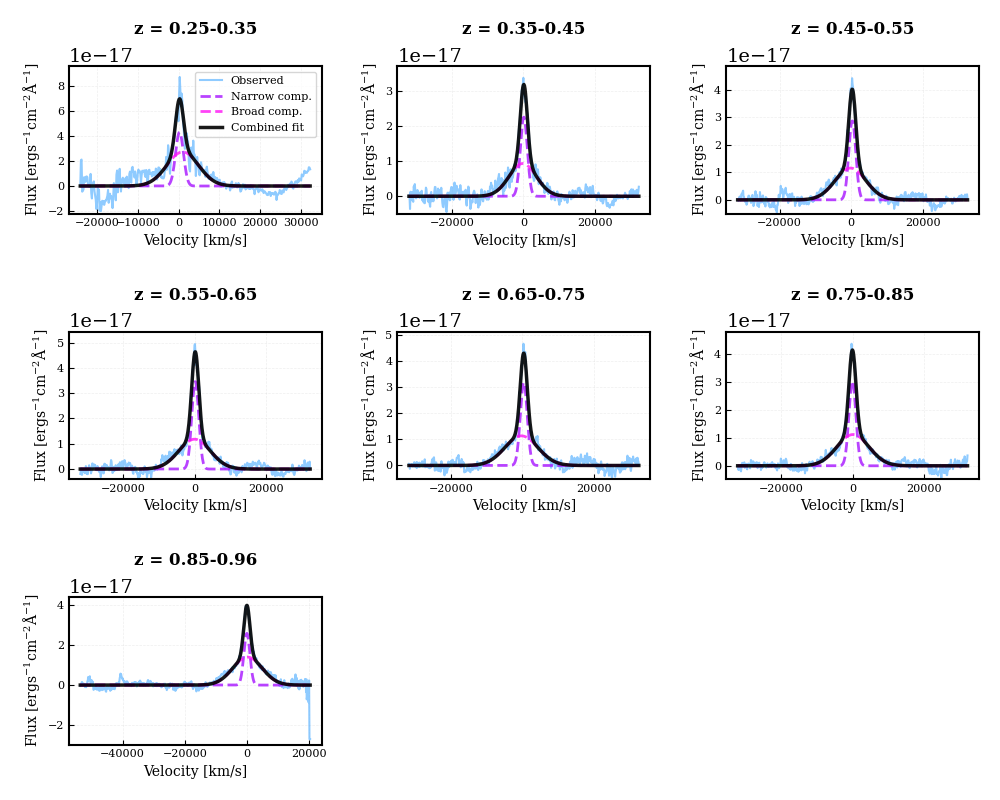

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Define redshift bins
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']

# Create the 3x3 grid plot (using only 7 out of 9 subplots)
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

# Flatten axes array for easier indexing
axes = axes.flatten()

for i, (redshift_bin, redshift_label) in enumerate(zip(redshift_bins, redshift_labels)):
    # Use only the first 7 subplots (indices 0-6)
    if i >= 7:
        break
        
    ax = axes[i]
    
    try:
        # Get MgII spectral data and fit parameters
        velocity = eval(f'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_{redshift_bin}')
        
        # Get Gaussian fit parameters - different naming for 025_035
        if redshift_bin == '025_035':
            # FeII_Removed naming convention for 025_035
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_{redshift_bin}')
            narrow_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            broad_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            best_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_{redshift_bin}')
        else:
            # Standard naming convention for other redshift bins
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_{redshift_bin}')
            narrow_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            broad_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            best_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_{redshift_bin}')

        # Plot the observed spectrum
        ax.plot(velocity, flux, color='#60B5FF', linewidth=1.5, alpha=0.7, label='Observed')
        
        ax.plot(velocity, narrow_fit, '--', color='#a714ff', linewidth=2, 
                alpha=0.8, label='Narrow comp.')
        ax.plot(velocity, broad_fit, '--', color='#ff14f5', linewidth=2, 
                alpha=0.8, label='Broad comp.')
        
        # Plot the combined best fit
        ax.plot(velocity, best_fit, '-', color='black', linewidth=2.5, 
                alpha=0.9, label='Combined fit')
        
        # Formatting
        ax.set_xlabel('Velocity [km/s]', fontsize=10)
        ax.set_ylabel(r'Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', fontsize=10)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        # Only show legend in the first plot
        if i == 0:
            ax.legend(fontsize=8, loc='upper right')
        
        # Add redshift label as title for each subplot
        ax.set_title(f'z = {redshift_label}', fontsize=12, weight='bold', pad=10)
        
        # Set reasonable y-limits
        ax.set_ylim(np.min(flux) * 1.1, np.max([np.max(flux), np.max(best_fit)]) * 1.1)
        
    except NameError as e:
        ax.text(0.5, 0.5, f'MgII Spectrum\n{redshift_bin}\n(Variables not found:\n{str(e)})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8))
        ax.set_xlabel('Velocity [km/s]', fontsize=10)
        ax.set_ylabel(r'Flux [$erg s^{-1} cm^{-2} \AA^{-1}$]', fontsize=10)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        ax.set_title(f'z = {redshift_label}', fontsize=12, weight='bold', pad=10)

# Hide the unused subplots (indices 7 and 8)
for i in range(7, 9):
    axes[i].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(hspace=0.8, wspace=0.3)

# Save the figure
plt.savefig('/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/MgII_spectral_fits_3x3.png', dpi=300, bbox_inches='tight')
plt.show()


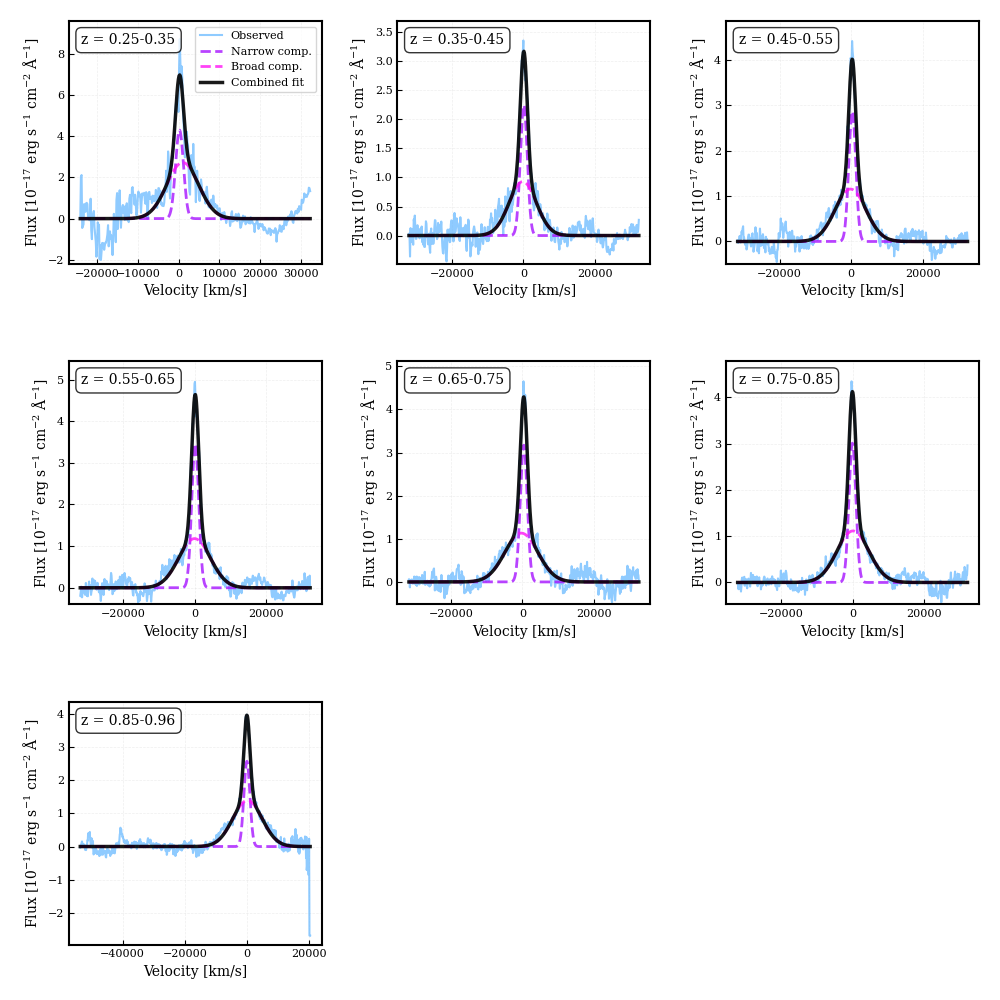

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define redshift bins
redshift_bins = ['025_035', '035_045', '045_055', '055_065', '065_075', '075_085', '085_096']
redshift_labels = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', '0.65-0.75', '0.75-0.85', '0.85-0.96']

# Create the 3x3 grid plot (using only 7 out of 9 subplots)
# Increased height from 8 to 10
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Flatten axes array for easier indexing
axes = axes.flatten()

for i, (redshift_bin, redshift_label) in enumerate(zip(redshift_bins, redshift_labels)):
    # Use only the first 7 subplots (indices 0-6)
    if i >= 7:
        break
        
    ax = axes[i]
    
    try:
        # Get MgII spectral data and fit parameters
        velocity = eval(f'MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_{redshift_bin}')
        
        # Get Gaussian fit parameters - different naming for 025_035
        if redshift_bin == '025_035':
            # FeII_Removed naming convention for 025_035
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_FeII_Removed_{redshift_bin}')
            narrow_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            broad_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            best_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_{redshift_bin}')
        else:
            # Standard naming convention for other redshift bins
            flux = eval(f'MgII_Continuum_Removed_ReStacked_Continuum_Scaled_{redshift_bin}')
            narrow_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Narrow_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            broad_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_{redshift_bin}')
            best_fit = eval(f'MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_{redshift_bin}')

        # Scale flux values by 1e17
        flux_scaled = flux * 1e17
        narrow_fit_scaled = narrow_fit * 1e17
        broad_fit_scaled = broad_fit * 1e17
        best_fit_scaled = best_fit * 1e17

        # Plot the observed spectrum
        ax.plot(velocity, flux_scaled, color='#60B5FF', linewidth=1.5, alpha=0.7, label='Observed')
        
        ax.plot(velocity, narrow_fit_scaled, '--', color='#a714ff', linewidth=2, 
                alpha=0.8, label='Narrow comp.')
        ax.plot(velocity, broad_fit_scaled, '--', color='#ff14f5', linewidth=2, 
                alpha=0.8, label='Broad comp.')
        
        # Plot the combined best fit
        ax.plot(velocity, best_fit_scaled, '-', color='black', linewidth=2.5, 
                alpha=0.9, label='Combined fit')
        
        # Formatting
        ax.set_xlabel('Velocity [km/s]', fontsize=10)
        ax.set_ylabel(r'Flux [$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=10)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
        
        # Only show legend in the first plot
        if i == 0:
            ax.legend(fontsize=8, loc='upper right')
        
        # Add redshift label in upper left corner
        ax.text(0.05, 0.95, f'z = {redshift_label}', 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='black', alpha=0.8))
        
        # Set reasonable y-limits
        ax.set_ylim(np.min(flux_scaled) * 1.1, np.max([np.max(flux_scaled), np.max(best_fit_scaled)]) * 1.1)
        
    except NameError as e:
        ax.text(0.5, 0.5, f'MgII Spectrum\n{redshift_bin}\n(Variables not found:\n{str(e)})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.8))
        ax.set_xlabel('Velocity [km/s]', fontsize=10)
        ax.set_ylabel(r'Flux [$10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=10)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Hide the unused subplots (indices 7 and 8)
for i in range(7, 9):
    axes[i].set_visible(False)

# Adjust layout
plt.tight_layout()
# Reduced hspace from 0.8 to 0.4 for less vertical spacing
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Save the figure
plt.savefig('/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/MgII_spectral_fits_3x3.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
pwd